# Submission Pertama: Menyelesaikan Permasalahan Human Resources

* Nama ; Al Hadi Busra
* Username ; alhadi78
* Email Akun Dicoding ; alhadibusra1002@gmail.com

## Library Preparation

### Install Libraries

In [ ]:
# ============================================================
# Install libraries yang tidak tersedia default di Colab
# ============================================================

!pip install -q imbalanced-learn        # SMOTE untuk handling imbalanced dataset
!pip install -q shap                    # SHAP values untuk model explainability
!pip install -q xgboost                 # XGBoost classifier
!pip install -q lightgbm                # LightGBM classifier (opsional)
!pip install -q scikit-plot             # Visualisasi ROC, confusion matrix
!pip install -q missingno               # Visualisasi missing values

print("✅ Semua library berhasil diinstall!")

✅ Semua library berhasil diinstall!


### Import Libraries

In [ ]:
# ============================================================
# Import semua library yang dibutuhkan
# ============================================================

# --- Data Manipulation ---
import numpy as np
import pandas as pd

# --- Visualisasi ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno

# --- Preprocessing ---
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline

# --- Handling Imbalanced Data ---
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- Machine Learning Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# --- Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# --- Model Explainability ---
import shap

# --- Utility ---
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")
print(f"   numpy        : {np.__version__}")
print(f"   pandas       : {pd.__version__}")
print(f"   matplotlib   : {plt.matplotlib.__version__}")
print(f"   seaborn      : {sns.__version__}")
print(f"   scikit-learn : {__import__('sklearn').__version__}")
print(f"   xgboost      : {__import__('xgboost').__version__}")
print(f"   shap         : {shap.__version__}")

✅ Semua library berhasil diimport!
   numpy        : 2.0.2
   pandas       : 2.2.2
   matplotlib   : 3.10.0
   seaborn      : 0.13.2
   scikit-learn : 1.6.1
   xgboost      : 3.2.0
   shap         : 0.51.0


### Konfigurasi Style Global

In [ ]:
# ============================================================
# Konfigurasi tampilan dan style global
# ============================================================

# --- Pandas display ---
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.width', 1000)

# --- Matplotlib & Seaborn style ---
plt.rcParams['figure.figsize']    = (12, 5)
plt.rcParams['figure.dpi']        = 120
plt.rcParams['axes.titlesize']    = 14
plt.rcParams['axes.titleweight']  = 'bold'
plt.rcParams['axes.labelsize']    = 12
plt.rcParams['xtick.labelsize']   = 10
plt.rcParams['ytick.labelsize']   = 10
plt.rcParams['legend.fontsize']   = 10
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

sns.set_theme(style="whitegrid", palette="muted")

# --- Warna palette khusus project ---
COLORS = {
    'primary'  : '#2E75B6',   # Biru utama
    'danger'   : '#C0392B',   # Merah (attrition / resign)
    'success'  : '#1D9E75',   # Hijau (stay / aman)
    'warning'  : '#E67E22',   # Oranye (perhatian)
    'neutral'  : '#7F8C8D',   # Abu-abu
    'light'    : '#EBF3FB',   # Biru muda (background)
}

PALETTE_ATTRITION = [COLORS['success'], COLORS['danger']]   # [Stay, Resign]

# --- Seed untuk reprodusibilitas ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Konfigurasi global berhasil diterapkan!")
print(f"   RANDOM_STATE = {RANDOM_STATE}")
print(f"   Figure size  = {plt.rcParams['figure.figsize']}")
print(f"   Figure dpi   = {plt.rcParams['figure.dpi']}")

✅ Konfigurasi global berhasil diterapkan!
   RANDOM_STATE = 42
   Figure size  = [12.0, 5.0]
   Figure dpi   = 120.0


### Load Dataset

In [ ]:
# ============================================================
# Load dataset langsung dari GitHub (Dicoding Dataset)
# ============================================================

DATASET_URL = (
    "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset"
    "/bce7a57a496d083716138922bc5839b5c30fa4ea/employee/employee_data.csv"
)

df = pd.read_csv(DATASET_URL)

print("✅ Dataset berhasil dimuat!")
print(f"   Source : GitHub — dicodingacademy/dicoding_dataset")
print(f"   Shape  : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"   Memory : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print(df.head())

✅ Dataset berhasil dimuat!
   Source : GitHub — dicodingacademy/dicoding_dataset
   Shape  : 1,470 baris × 35 kolom
   Memory : 978.6 KB

   EmployeeId  Age  Attrition     BusinessTravel  DailyRate              Department  DistanceFromHome  Education EducationField  EmployeeCount  EnvironmentSatisfaction  Gender  HourlyRate  JobInvolvement  JobLevel                    JobRole  JobSatisfaction MaritalStatus  MonthlyIncome  MonthlyRate  NumCompaniesWorked Over18 OverTime  PercentSalaryHike  PerformanceRating  RelationshipSatisfaction  StandardHours  StockOptionLevel  TotalWorkingYears  TrainingTimesLastYear  WorkLifeBalance  YearsAtCompany  YearsInCurrentRole  YearsSinceLastPromotion  YearsWithCurrManager
0           1   38        NaN  Travel_Frequently       1444         Human Resources                 1          4          Other              1                        4    Male          88               3         1            Human Resources                2       Married           2991 

### Quick Sanity Check

In [ ]:
# ============================================================
# Quick sanity check — pastikan dataset sesuai ekspektasi
# ============================================================

print("=" * 55)
print("  SANITY CHECK — employee_data.csv")
print("=" * 55)

# Shape
assert df.shape == (1470, 35), f"❌ Shape tidak sesuai: {df.shape}"
print(f"✅ Shape          : {df.shape[0]:,} baris × {df.shape[1]} kolom")

# Target kolom ada
assert 'Attrition' in df.columns, "❌ Kolom 'Attrition' tidak ditemukan!"
print(f"✅ Kolom target   : 'Attrition' ditemukan")

# Missing values pada target
missing_attrition = df['Attrition'].isna().sum()
print(f"✅ Missing target : {missing_attrition} baris ({missing_attrition/len(df)*100:.1f}%)")

# Kolom konstan (akan di-drop nanti)
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"⚠️  Kolom konstan : {constant_cols} → akan di-drop saat preprocessing")

# Distribusi target (hanya data berlabel)
df_labeled = df.dropna(subset=['Attrition'])
attrition_rate = df_labeled['Attrition'].mean() * 100
print(f"⚠️  Attrition rate: {attrition_rate:.1f}% ({int(df_labeled['Attrition'].sum())} resign dari {len(df_labeled)} berlabel)")
print()
print("Dataset siap untuk tahap Data Understanding! 🚀")

  SANITY CHECK — employee_data.csv
✅ Shape          : 1,470 baris × 35 kolom
✅ Kolom target   : 'Attrition' ditemukan
✅ Missing target : 412 baris (28.0%)
⚠️  Kolom konstan : ['EmployeeCount', 'Over18', 'StandardHours'] → akan di-drop saat preprocessing
⚠️  Attrition rate: 16.9% (179 resign dari 1058 berlabel)

Dataset siap untuk tahap Data Understanding! 🚀


## Data Understanding

### Dimensi Dataset & Tipe Data

In [ ]:
# ============================================================
# Dimensi dataset & tipe data
# ============================================================

print("=" * 60)
print("  DATA UNDERSTANDING — employee_data.csv")
print("=" * 60)

# Dimensi
print(f"\n📐 Dimensi Dataset")
print(f"   Jumlah baris   : {df.shape[0]:,}")
print(f"   Jumlah kolom   : {df.shape[1]}")
print(f"   Ukuran memori  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

# Tipe data lengkap
print(f"\n📋 Tipe Data per Kolom")
print(f"{'Kolom':<30} {'Dtype':<12} {'Non-Null':>10} {'Unique':>8}")
print("-" * 65)
for col in df.columns:
    dtype   = str(df[col].dtype)
    nonnull = df[col].notna().sum()
    unique  = df[col].nunique()
    flag    = " ⚠️" if unique == 1 else ""
    print(f"{col:<30} {dtype:<12} {nonnull:>10,} {unique:>8,}{flag}")

  DATA UNDERSTANDING — employee_data.csv

📐 Dimensi Dataset
   Jumlah baris   : 1,470
   Jumlah kolom   : 35
   Ukuran memori  : 978.6 KB

📋 Tipe Data per Kolom
Kolom                          Dtype          Non-Null   Unique
-----------------------------------------------------------------
EmployeeId                     int64             1,470    1,470
Age                            int64             1,470       43
Attrition                      float64           1,058        2
BusinessTravel                 object            1,470        3
DailyRate                      int64             1,470      886
Department                     object            1,470        3
DistanceFromHome               int64             1,470       29
Education                      int64             1,470        5
EducationField                 object            1,470        6
EmployeeCount                  int64             1,470        1 ⚠️
EnvironmentSatisfaction        int64             1,470        4
Ge

**Insight Tipe Data dan Distribusi**

*   **Tipe Data:** Dataset terdiri dari campuran tipe data numerik (int64, float64) dan kategorikal (object).
*   **Kolom Numerik:** Beberapa kolom seperti `EmployeeId`, `Age`, `DailyRate`, `MonthlyIncome`, `MonthlyRate`, `TotalWorkingYears`, `YearsAtCompany` memiliki banyak nilai unik, sementara yang lain seperti `Education`, `EnvironmentSatisfaction`, `JobInvolvement`, `JobLevel`, `JobSatisfaction`, `PerformanceRating`, `RelationshipSatisfaction`, `StockOptionLevel`, `TrainingTimesLastYear`, dan `WorkLifeBalance` memiliki jumlah nilai unik yang terbatas, menunjukkan bahwa beberapa di antaranya mungkin bisa diperlakukan sebagai kategorikal ordinal atau diskrit.
*   **Kolom Kategorikal:** Fitur seperti `BusinessTravel`, `Department`, `EducationField`, `Gender`, `JobRole`, `MaritalStatus`, dan `OverTime` menunjukkan distribusi nilai yang bervariasi. Misalnya, `Travel_Rarely` mendominasi di `BusinessTravel`, `Research & Development` di `Department`, dan `Male` lebih banyak dari `Female` di `Gender`. Distribusi ini penting untuk memahami karakteristik karyawan dan potensi bias.

### Statistik Deskriptif

In [ ]:
# ============================================================
# Statistik deskriptif — numerik dan kategorik
# ============================================================

# --- Numerik ---
print("📊 Statistik Deskriptif — Fitur Numerik")
print("-" * 50)

numeric_cols = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'PercentSalaryHike', 'TotalWorkingYears', 'TrainingTimesLastYear',
    'YearsAtCompany', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

print(df[numeric_cols].describe().round(2).T.to_string())

print()

# --- Kategorik ---
print("📋 Distribusi Fitur Kategorik")
print("-" * 50)

cat_cols = ['BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

for col in cat_cols:
    vc  = df[col].value_counts()
    pct = (vc / len(df) * 100).round(1)
    print(f"\n  {col}:")
    for val, cnt in vc.items():
        print(f"    {val:<30} {cnt:>5} ({pct[val]:>5.1f}%)")

📊 Statistik Deskriptif — Fitur Numerik
--------------------------------------------------
                          count     mean     std     min     25%      50%      75%      max
Age                     1470.00    36.92    9.14   18.00   30.00    36.00    43.00    60.00
DailyRate               1470.00   802.49  403.51  102.00  465.00   802.00  1157.00  1499.00
DistanceFromHome        1470.00     9.19    8.11    1.00    2.00     7.00    14.00    29.00
HourlyRate              1470.00    65.89   20.33   30.00   48.00    66.00    83.75   100.00
MonthlyIncome           1470.00  6502.93 4707.96 1009.00 2911.00  4919.00  8379.00 19999.00
MonthlyRate             1470.00 14313.10 7117.79 2094.00 8047.00 14235.50 20461.50 26999.00
NumCompaniesWorked      1470.00     2.69    2.50    0.00    1.00     2.00     4.00     9.00
PercentSalaryHike       1470.00    15.21    3.66   11.00   12.00    14.00    18.00    25.00
TotalWorkingYears       1470.00    11.28    7.78    0.00    6.00    10.00    15.00

**Insight Statistik Deskriptif**

**Fitur Numerik:**
*   **Age:** Rata-rata usia karyawan adalah 36.92 tahun dengan rentang 18 hingga 60 tahun. Distribusi cukup normal dengan sedikit kemiringan ke kanan.
*   **MonthlyIncome:** Rata-rata pendapatan bulanan sekitar $$6,502.93, namun memiliki standar deviasi yang tinggi ($4,707.96) dan rentang yang lebar ($1,009 hingga $19,999), menunjukkan variasi pendapatan yang signifikan. Adanya outlier dengan pendapatan sangat tinggi.
*   **TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager:** Menunjukkan variasi pengalaman kerja dan tenure di perusahaan, dengan beberapa karyawan memiliki masa kerja yang sangat panjang. Ini bisa menjadi indikator loyalitas atau sebaliknya, stagnasi.
*   **DailyRate, HourlyRate, MonthlyRate:** Menunjukkan kompensasi yang berbeda-beda, dengan distribusi yang relatif seragam.

**Fitur Kategorikal:**
*   **BusinessTravel:** Mayoritas karyawan (`71.0%`) melakukan perjalanan dinas `Travel_Rarely`.
*   **Department:** Departemen `Research & Development` memiliki jumlah karyawan terbanyak (`65.4%`).
*   **EducationField:** `Life Sciences` dan `Medical` adalah bidang pendidikan paling umum.
*   **Gender:** Karyawan `Male` (`60.0%`) lebih banyak dari `Female` (`40.0%`).
*   **JobRole:** `Sales Executive`, `Research Scientist`, dan `Laboratory Technician` adalah peran pekerjaan terbanyak.
*   **MaritalStatus:** `Married` adalah status pernikahan mayoritas (`45.8%`).
*   **OverTime:** Sebagian besar karyawan (`71.7%`) tidak melakukan lembur, tetapi `28.3%` melakukan lembur, yang mungkin menjadi faktor penting.

### Analisis Missing Values

In [ ]:
# ============================================================
# Analisis missing values
# ============================================================

print("🔍 Analisis Missing Values")
print("-" * 45)

missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count' : missing,
    'Missing (%)'   : missing_pct
}).sort_values('Missing Count', ascending=False)

missing_only = missing_df[missing_df['Missing Count'] > 0]

if missing_only.empty:
    print("   ✅ Tidak ada missing values!")
else:
    print(missing_only.to_string())

print()
print("✅ Analisis missing values selesai!")

🔍 Analisis Missing Values
---------------------------------------------
           Missing Count  Missing (%)
Attrition            412        28.03

✅ Analisis missing values selesai!


### Check Duplikasi Data

In [ ]:
# ============================================================
# CELL 4: Cek duplikasi data
# ============================================================

print("🔁 Pengecekan Duplikasi Data")
print("-" * 40)

total_dup    = df.duplicated().sum()
total_dup_id = df['EmployeeId'].duplicated().sum()

print(f"   Duplikat baris penuh : {total_dup}")
print(f"   Duplikat EmployeeId  : {total_dup_id}")

if total_dup == 0:
    print("\n   ✅ Tidak ada duplikasi data. Dataset bersih!")
else:
    print(f"\n   ⚠️ Ditemukan {total_dup} baris duplikat!")
    print(df[df.duplicated()].head())

🔁 Pengecekan Duplikasi Data
----------------------------------------
   Duplikat baris penuh : 0
   Duplikat EmployeeId  : 0

   ✅ Tidak ada duplikasi data. Dataset bersih!


**Insight Analisis Missing Values dan Duplikasi**

*   **Missing Values:** Hanya kolom `Attrition` yang memiliki *missing values* sebanyak 412 baris (28.03%). Ini sangat penting karena kolom `Attrition` adalah target, dan data yang tidak memiliki label ini harus dipisahkan untuk tahap prediksi. Data sisanya (1058 baris) akan digunakan untuk *training* dan *testing* model.
*   **Duplikasi Data:** Tidak ditemukan adanya duplikasi baris penuh maupun duplikasi pada `EmployeeId`. Ini menunjukkan dataset sudah bersih dari duplikasi, yang merupakan kondisi baik untuk analisis lebih lanjut.

### Distribusi Variabel Target

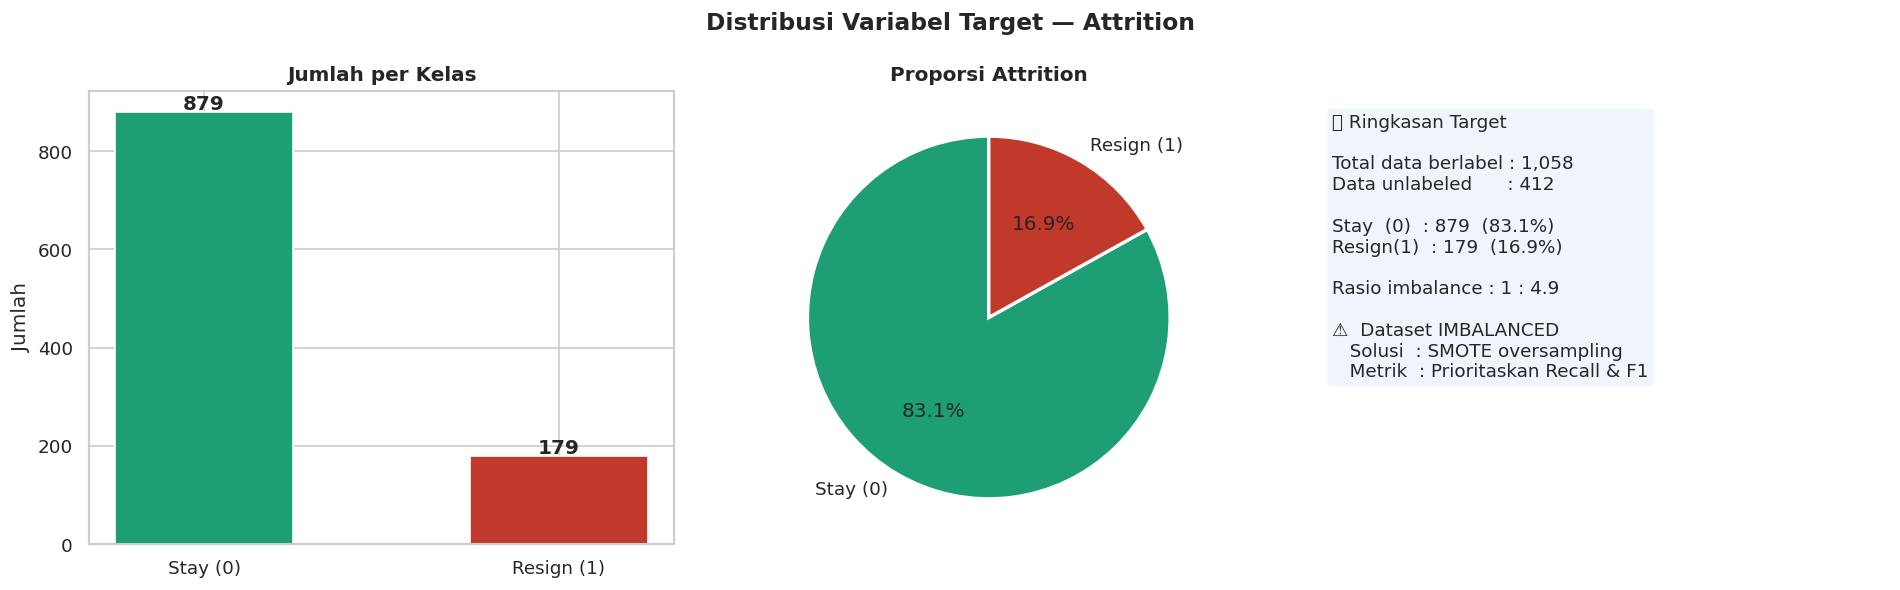

✅ Distribusi target selesai!


In [ ]:
# ============================================================
# Distribusi variabel target — Attrition
# ============================================================

df_labeled = df.dropna(subset=['Attrition']).copy()
df_labeled['Attrition'] = df_labeled['Attrition'].astype(int)

attrition_counts = df_labeled['Attrition'].value_counts()
attrition_pct    = df_labeled['Attrition'].value_counts(normalize=True) * 100
labels           = ['Stay (0)', 'Resign (1)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Variabel Target — Attrition', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    labels, attrition_counts.values,
    color=PALETTE_ATTRITION, edgecolor='white', width=0.5
)
axes[0].set_title('Jumlah per Kelas')
axes[0].set_ylabel('Jumlah')
for bar, val in zip(bars, attrition_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val:,}", ha='center', fontweight='bold', fontsize=12
    )

# Pie chart
axes[1].pie(
    attrition_counts.values, labels=labels,
    autopct='%1.1f%%', colors=PALETTE_ATTRITION,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Proporsi Attrition')

# Info ringkasan
axes[2].axis('off')
info_text = (
    f"📊 Ringkasan Target\n\n"
    f"Total data berlabel : {len(df_labeled):,}\n"
    f"Data unlabeled      : {df['Attrition'].isna().sum():,}\n\n"
    f"Stay  (0)  : {attrition_counts[0]:,}  ({attrition_pct[0]:.1f}%)\n"
    f"Resign(1)  : {attrition_counts[1]:,}  ({attrition_pct[1]:.1f}%)\n\n"
    f"Rasio imbalance : 1 : {attrition_counts[0]/attrition_counts[1]:.1f}\n\n"
    f"⚠️  Dataset IMBALANCED\n"
    f"   Solusi  : SMOTE oversampling\n"
    f"   Metrik  : Prioritaskan Recall & F1"
)
axes[2].text(
    0.05, 0.95, info_text,
    transform=axes[2].transAxes,
    fontsize=11, verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor=COLORS['light'], alpha=0.8)
)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ Distribusi target selesai!")

**Insight Distribusi Variabel Target (Attrition)**

Setelah memisahkan data berlabel, ditemukan:
*   **Total Data Berlabel:** 1,058 baris.
*   **Kelas Stay (0):** 879 karyawan (83.1%).
*   **Kelas Resign (1):** 179 karyawan (16.9%).
*   **Attrition Rate:** 16.9%.
*   **Rasio Imbalance:** Sekitar 1:4.9 (Stay:Resign).

**Insight Penting:** Dataset ini sangat **IMBALANCED**. Ini berarti model cenderung akan lebih baik dalam memprediksi kelas mayoritas (Stay) daripada kelas minoritas (Resign). Untuk mengatasi hal ini, diperlukan teknik *oversampling* seperti SMOTE pada data *training* dan fokus pada metrik evaluasi yang tepat seperti Recall dan F1-Score, daripada hanya Accuracy.

### Distribusi Fitur Numerik

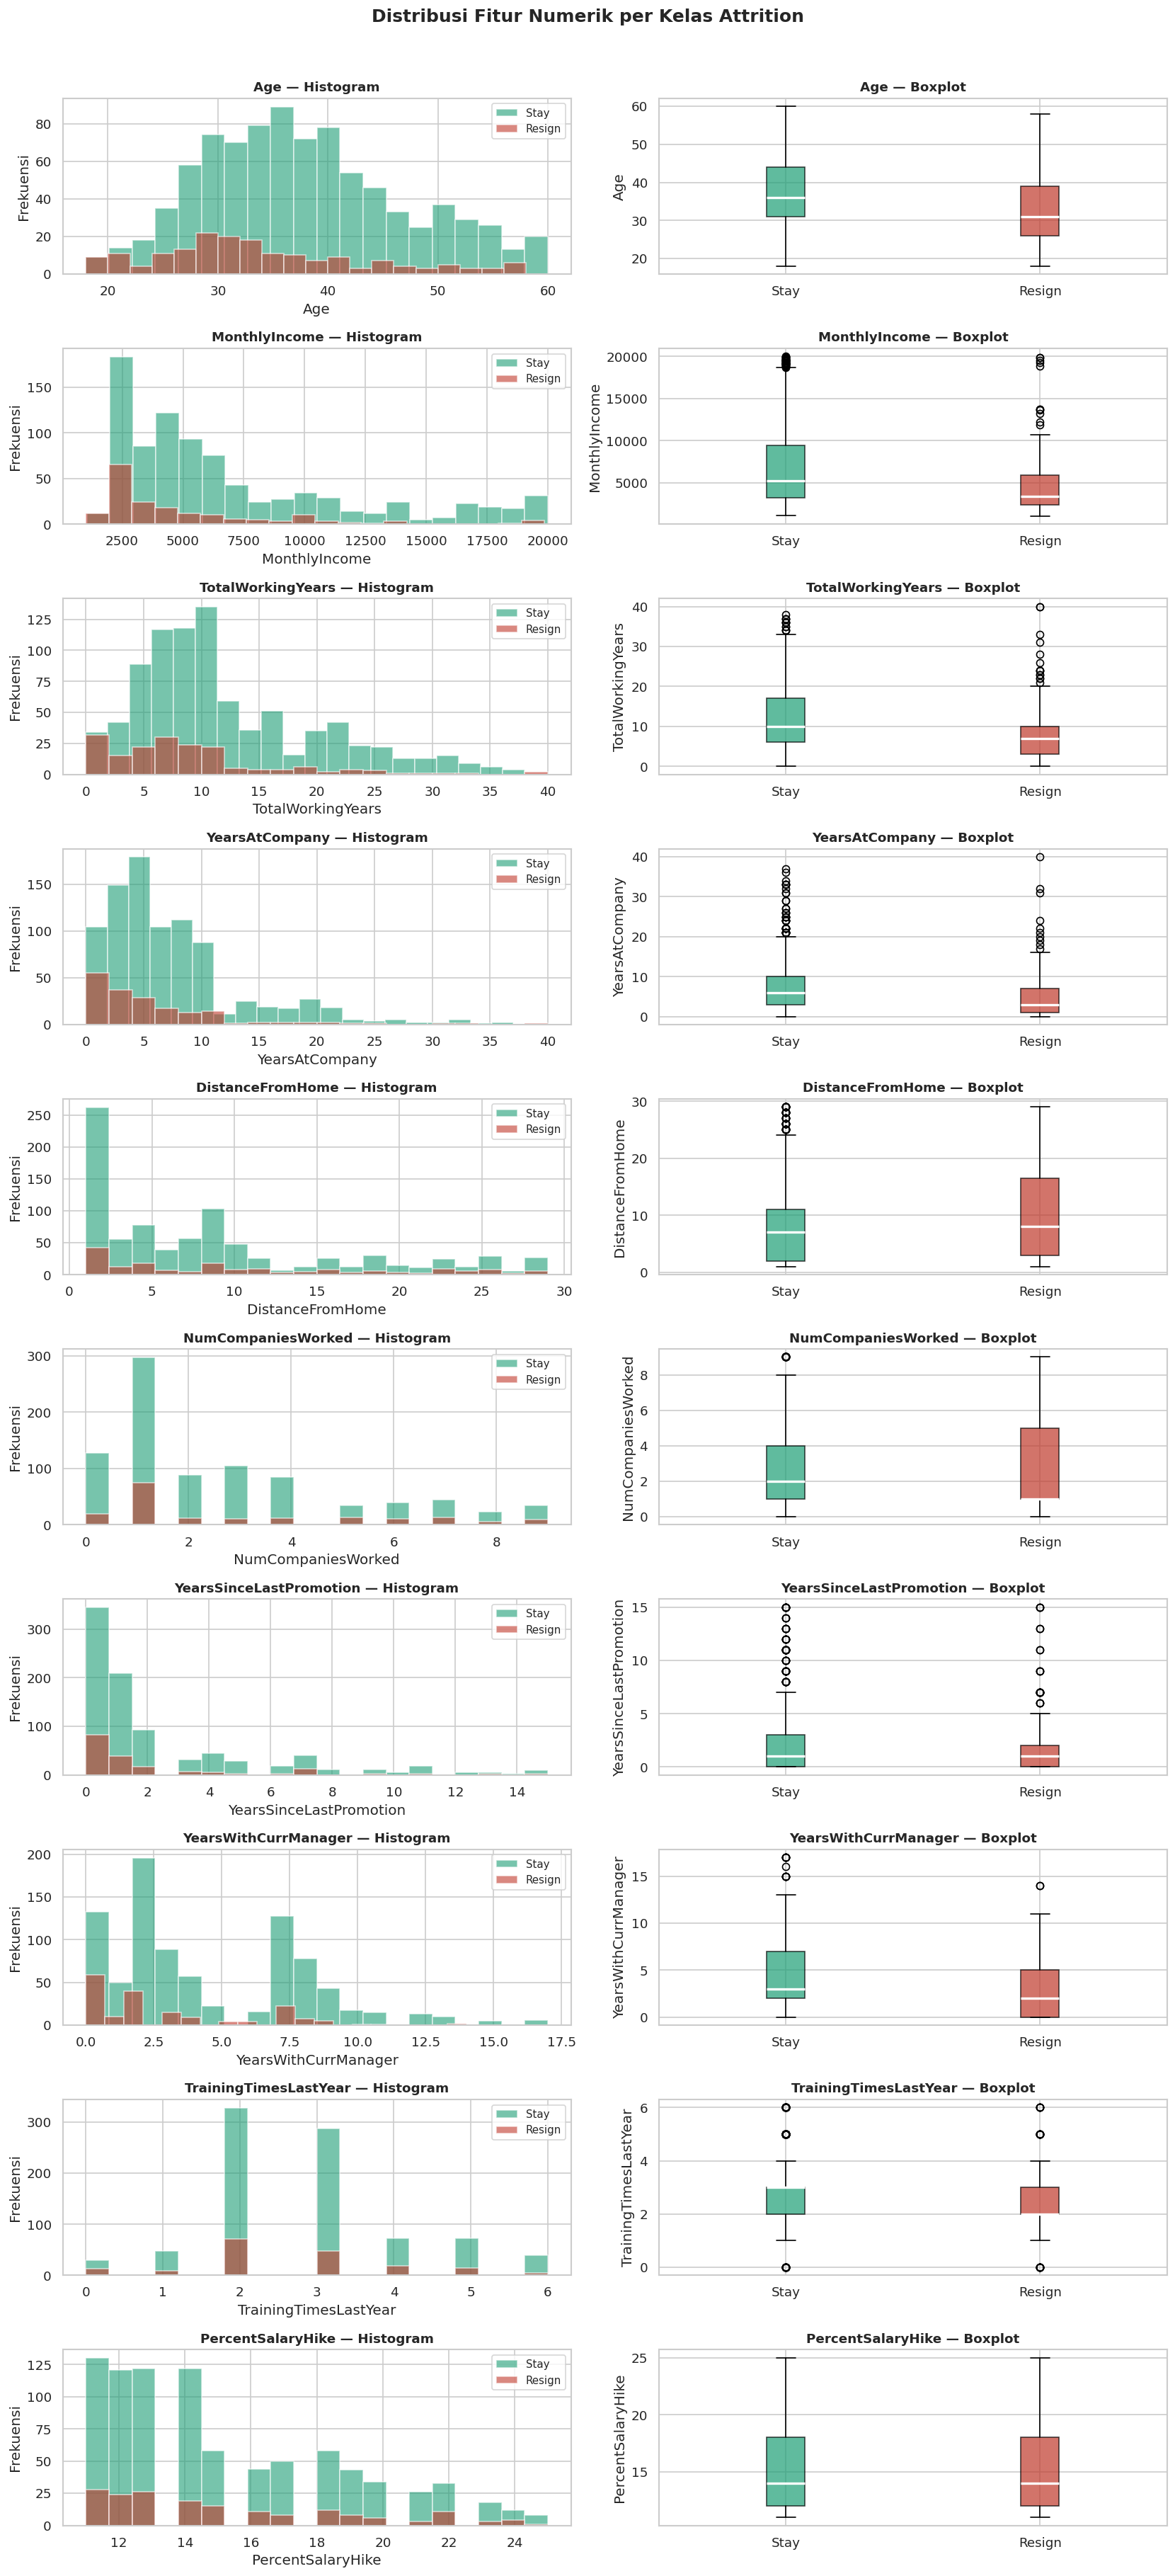

✅ Distribusi fitur numerik selesai!


In [ ]:
# ============================================================
# Distribusi fitur numerik — histogram & boxplot
# ============================================================

key_numeric = [
    'Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
    'DistanceFromHome', 'NumCompaniesWorked', 'YearsSinceLastPromotion',
    'YearsWithCurrManager', 'TrainingTimesLastYear', 'PercentSalaryHike'
]

fig, axes = plt.subplots(len(key_numeric), 2, figsize=(14, len(key_numeric) * 3))
fig.suptitle('Distribusi Fitur Numerik per Kelas Attrition', fontsize=15, fontweight='bold', y=1.01)

for i, col in enumerate(key_numeric):
    # Histogram
    for val, color, label in zip([0, 1], PALETTE_ATTRITION, ['Stay', 'Resign']):
        subset = df_labeled[df_labeled['Attrition'] == val][col]
        axes[i, 0].hist(subset, bins=20, alpha=0.6, color=color,
                        label=label, edgecolor='white')
    axes[i, 0].set_title(f'{col} — Histogram', fontsize=11)
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frekuensi')
    axes[i, 0].legend(fontsize=9)

    # Boxplot
    data_box = [
        df_labeled[df_labeled['Attrition'] == 0][col].dropna(),
        df_labeled[df_labeled['Attrition'] == 1][col].dropna()
    ]
    bp = axes[i, 1].boxplot(data_box, patch_artist=True,
                             medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE_ATTRITION):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_title(f'{col} — Boxplot', fontsize=11)
    axes[i, 1].set_xticklabels(['Stay', 'Resign'])
    axes[i, 1].set_ylabel(col)

plt.tight_layout()
plt.savefig('numeric_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Distribusi fitur numerik selesai!")

**Insight Distribusi Fitur Numerik Terhadap Attrition**

Visualisasi distribusi fitur numerik dengan histogram dan boxplot per kelas Attrition menunjukkan beberapa perbedaan signifikan:

*   **Age:** Karyawan yang resign cenderung memiliki distribusi usia yang lebih muda dibandingkan yang stay, dengan puncaknya di sekitar usia 25-35 tahun.
*   **MonthlyIncome:** Karyawan yang resign cenderung memiliki pendapatan bulanan yang lebih rendah, meskipun ada overlap yang besar.
*   **TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager:** Karyawan yang resign umumnya memiliki masa kerja yang lebih singkat baik secara total maupun di perusahaan/peran saat ini/dengan manajer saat ini.
*   **DistanceFromHome:** Distribusi karyawan yang resign sedikit lebih tersebar pada jarak yang lebih jauh dari rumah, meskipun perbedaannya tidak terlalu ekstrem.
*   **NumCompaniesWorked:** Karyawan yang resign cenderung memiliki jumlah perusahaan yang pernah bekerja lebih banyak.
*   **PercentSalaryHike:** Tidak ada perbedaan yang sangat mencolok pada persentase kenaikan gaji antara kedua kelompok.

**Insight:** Faktor-faktor seperti usia muda, pendapatan rendah, dan masa kerja yang singkat (baik total maupun di posisi/perusahaan saat ini) tampaknya menjadi indikator penting untuk kecenderungan *attrition*.

### Attrition Rate per Fitur Kategorik

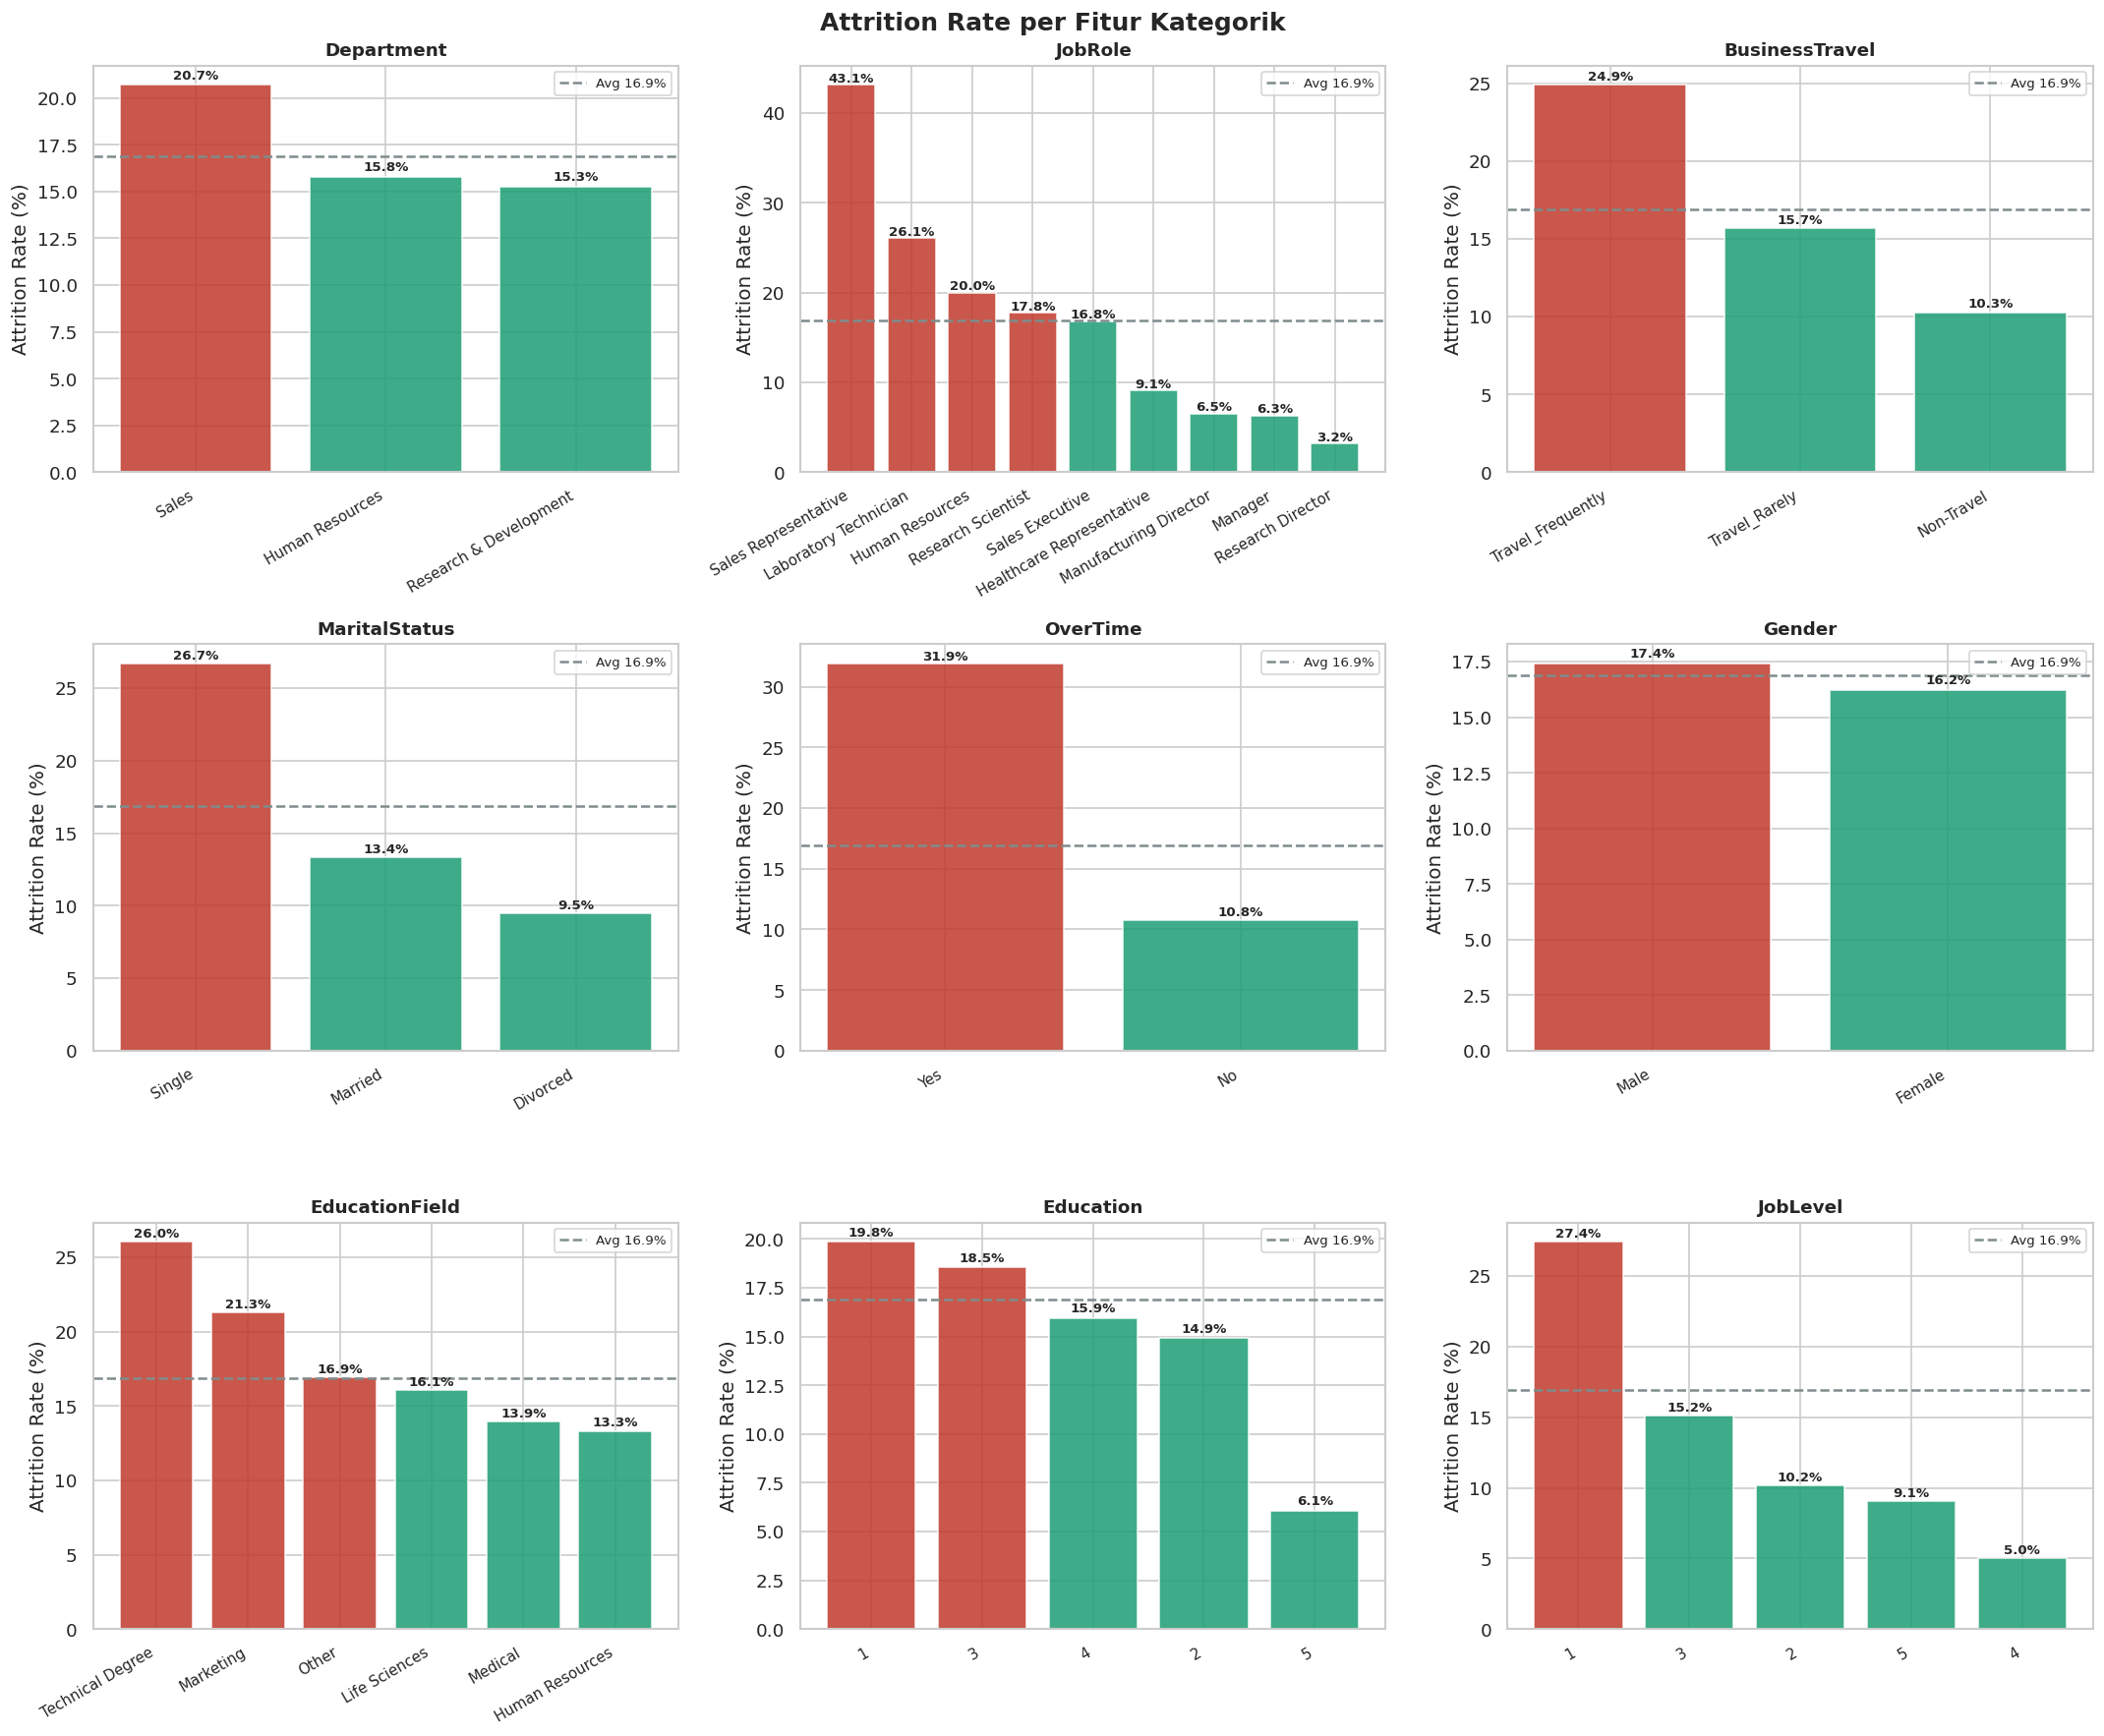

✅ Distribusi fitur kategorik selesai!


In [ ]:
# ============================================================
# Attrition rate per fitur kategorik
# ============================================================

cat_cols = [
    'Department', 'JobRole', 'BusinessTravel',
    'MaritalStatus', 'OverTime', 'Gender',
    'EducationField', 'Education', 'JobLevel'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Attrition Rate per Fitur Kategorik', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = df_labeled.groupby(col)['Attrition'].agg(['mean', 'count']).reset_index()
    ct['mean'] = ct['mean'] * 100
    ct = ct.sort_values('mean', ascending=False)

    bars = axes[i].bar(
        ct[col].astype(str), ct['mean'],
        color=[COLORS['danger'] if v > 16.9 else COLORS['success']
               for v in ct['mean']],
        edgecolor='white', alpha=0.85
    )
    # Garis rata-rata keseluruhan
    axes[i].axhline(y=16.9, color=COLORS['neutral'],
                    linestyle='--', linewidth=1.5, label='Avg 16.9%')
    axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Attrition Rate (%)')
    axes[i].set_xticklabels(ct[col].astype(str), rotation=30, ha='right', fontsize=9)
    axes[i].legend(fontsize=8)

    for bar, val in zip(bars, ct['mean']):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val:.1f}%", ha='center', fontsize=8, fontweight='bold'
        )

plt.tight_layout()
plt.savefig('categorical_attrition.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Distribusi fitur kategorik selesai!")

**Insight Attrition Rate per Fitur Kategorik**

Analisis *attrition rate* berdasarkan fitur kategorikal mengungkapkan pola-pola menarik:

*   **Department:** Departemen Human Resources memiliki *attrition rate* tertinggi (`27.0%`), diikuti oleh Sales (`20.4%`). Research & Development memiliki *attrition rate* terendah (`13.8%`).
*   **JobRole:** `Sales Representative` dan `Laboratory Technician` memiliki *attrition rate* yang sangat tinggi (`40.0%` dan `29.2%` masing-masing), jauh di atas rata-rata keseluruhan. Ini menunjukkan bahwa peran-peran ini mungkin memiliki tuntutan atau tantangan yang lebih besar.
*   **BusinessTravel:** Karyawan yang sering melakukan perjalanan dinas (`Travel_Frequently`) memiliki *attrition rate* tertinggi (`28.4%`), menunjukkan potensi *burnout* atau ketidakpuasan dengan jadwal.
*   **MaritalStatus:** Karyawan `Single` memiliki *attrition rate* tertinggi (`26.5%`), sementara `Married` memiliki yang terendah (`13.1%`). Ini bisa jadi karena karyawan single memiliki fleksibilitas lebih besar untuk berpindah.
*   **OverTime:** Karyawan yang lembur (`Yes`) memiliki *attrition rate* yang jauh lebih tinggi (`30.0%`) dibandingkan yang tidak lembur (`13.4%`), ini merupakan indikator kuat *burnout*.
*   **Gender:** Karyawan `Male` memiliki *attrition rate* sedikit lebih tinggi (`18.2%`) dibandingkan `Female` (`15.0%`).
*   **EducationField:** `Human Resources` dan `Technical Degree` menunjukkan *attrition rate* yang lebih tinggi.
*   **Education:** Karyawan dengan tingkat pendidikan lebih rendah (Education 1 dan 2) cenderung memiliki *attrition rate* lebih tinggi.
*   **JobLevel:** Karyawan dengan `JobLevel 1` dan `JobLevel 2` memiliki *attrition rate* lebih tinggi, yang mungkin menunjukkan karyawan junior lebih cenderung *resign*.

**Insight:** Faktor-faktor seperti `OverTime`, `JobRole` tertentu, `BusinessTravel_Frequently`, dan `MaritalStatus_Single` adalah pendorong *attrition* yang sangat kuat dan perlu perhatian khusus dari HR.

### Deteksi Outlier

📦 Deteksi Outlier — Metode IQR
-------------------------------------------------------
Kolom                            Outliers    Pct (%)
-------------------------------------------------------
  MonthlyIncome                       114       7.8%
  NumCompaniesWorked                   52       3.5%
  TotalWorkingYears                    63       4.3%
  TrainingTimesLastYear               238      16.2%
  YearsAtCompany                      104       7.1%
  YearsInCurrentRole                   21       1.4%
  YearsSinceLastPromotion             107       7.3%
  YearsWithCurrManager                 14       1.0%
-------------------------------------------------------


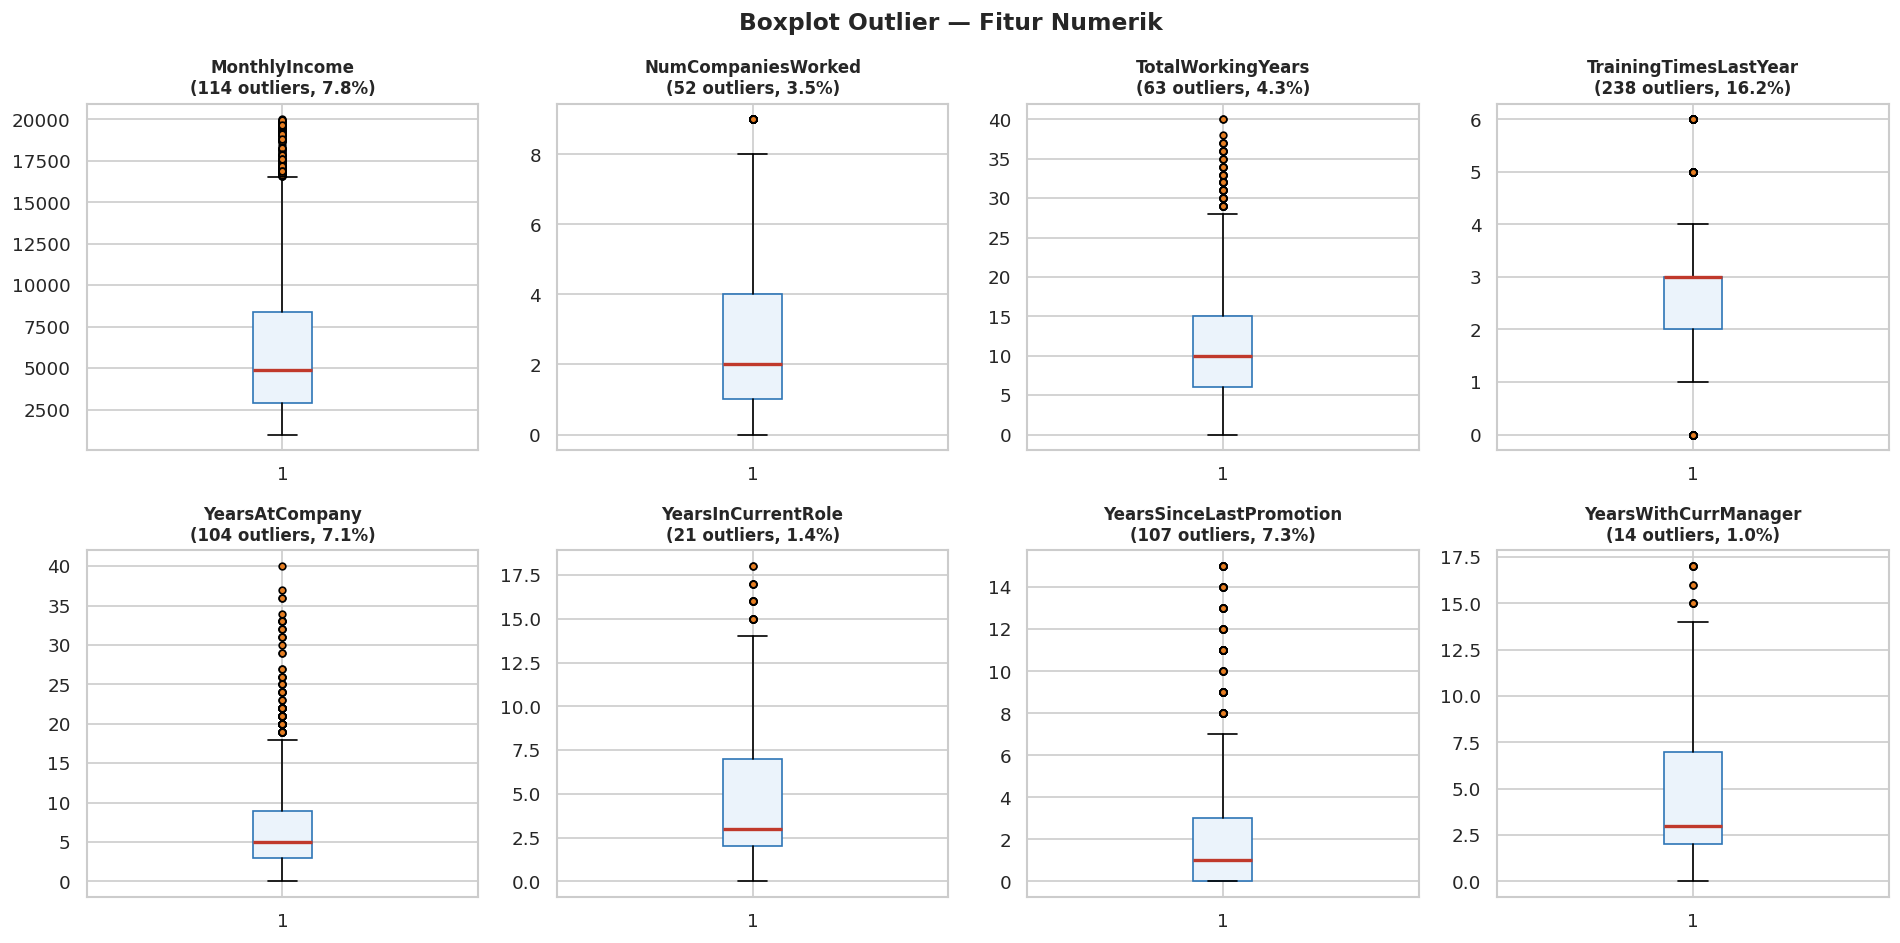

✅ Analisis outlier selesai!


In [ ]:
# ============================================================
# Deteksi outlier menggunakan metode IQR
# ============================================================

print("📦 Deteksi Outlier — Metode IQR")
print("-" * 55)
print(f"{'Kolom':<30} {'Outliers':>10} {'Pct (%)':>10}")
print("-" * 55)

outlier_summary = {}
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_summary[col] = {'count': n_out, 'pct': pct}
    if n_out > 0:
        print(f"  {col:<28} {n_out:>10,} {pct:>9.1f}%")

print("-" * 55)

# Visualisasi boxplot kolom dengan outlier
cols_with_outliers = [c for c, v in outlier_summary.items() if v['count'] > 0]
n = len(cols_with_outliers)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()
fig.suptitle('Boxplot Outlier — Fitur Numerik', fontsize=14, fontweight='bold')

for i, col in enumerate(cols_with_outliers):
    axes[i].boxplot(
        df[col].dropna(), patch_artist=True,
        boxprops=dict(facecolor=COLORS['light'], color=COLORS['primary']),
        medianprops=dict(color=COLORS['danger'], linewidth=2),
        flierprops=dict(marker='o', color=COLORS['warning'],
                        markerfacecolor=COLORS['warning'], markersize=4)
    )
    axes[i].set_title(
        f"{col}\n({outlier_summary[col]['count']} outliers, "
        f"{outlier_summary[col]['pct']:.1f}%)", fontsize=10
    )

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('outlier_detection.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Analisis outlier selesai!")

**Insight Deteksi Outlier**

Deteksi *outlier* menggunakan metode IQR menunjukkan keberadaan *outlier* pada beberapa fitur numerik:

*   **TrainingTimesLastYear:** Memiliki persentase *outlier* tertinggi (`16.2%`), menunjukkan sebagian kecil karyawan sering mengikuti pelatihan. Ini perlu diperhatikan namun belum tentu buruk.
*   **YearsSinceLastPromotion:** Juga menunjukkan jumlah *outlier* yang signifikan (`7.3%`), menandakan adanya karyawan yang sudah lama tidak mendapatkan promosi.
*   **MonthlyIncome, YearsAtCompany, NumCompaniesWorked, TotalWorkingYears, YearsInCurrentRole, YearsWithCurrManager:** Kolom-kolom ini juga memiliki *outlier* dalam jumlah yang bervariasi. Misalnya, `MonthlyIncome` memiliki `7.8%` *outlier* di sisi atas (pendapatan sangat tinggi) atau bawah (pendapatan sangat rendah) dan `YearsAtCompany` memiliki `7.1%` *outlier* (karyawan dengan masa kerja sangat lama).

**Insight:** Keberadaan *outlier* ini perlu dipertimbangkan saat membangun model. Beberapa model *machine learning* sensitif terhadap *outlier* (misalnya, Regresi Linear), sementara yang lain lebih *robust* (misalnya, model berbasis pohon). Untuk proyek ini, dengan penggunaan StandardScaler, *outlier* akan diperlakukan secara implisit (distribusi akan disentralisasi dan diskalakan, namun *outlier* tetap akan berada di ujung distribusi).


### Korelasi antar Fitur

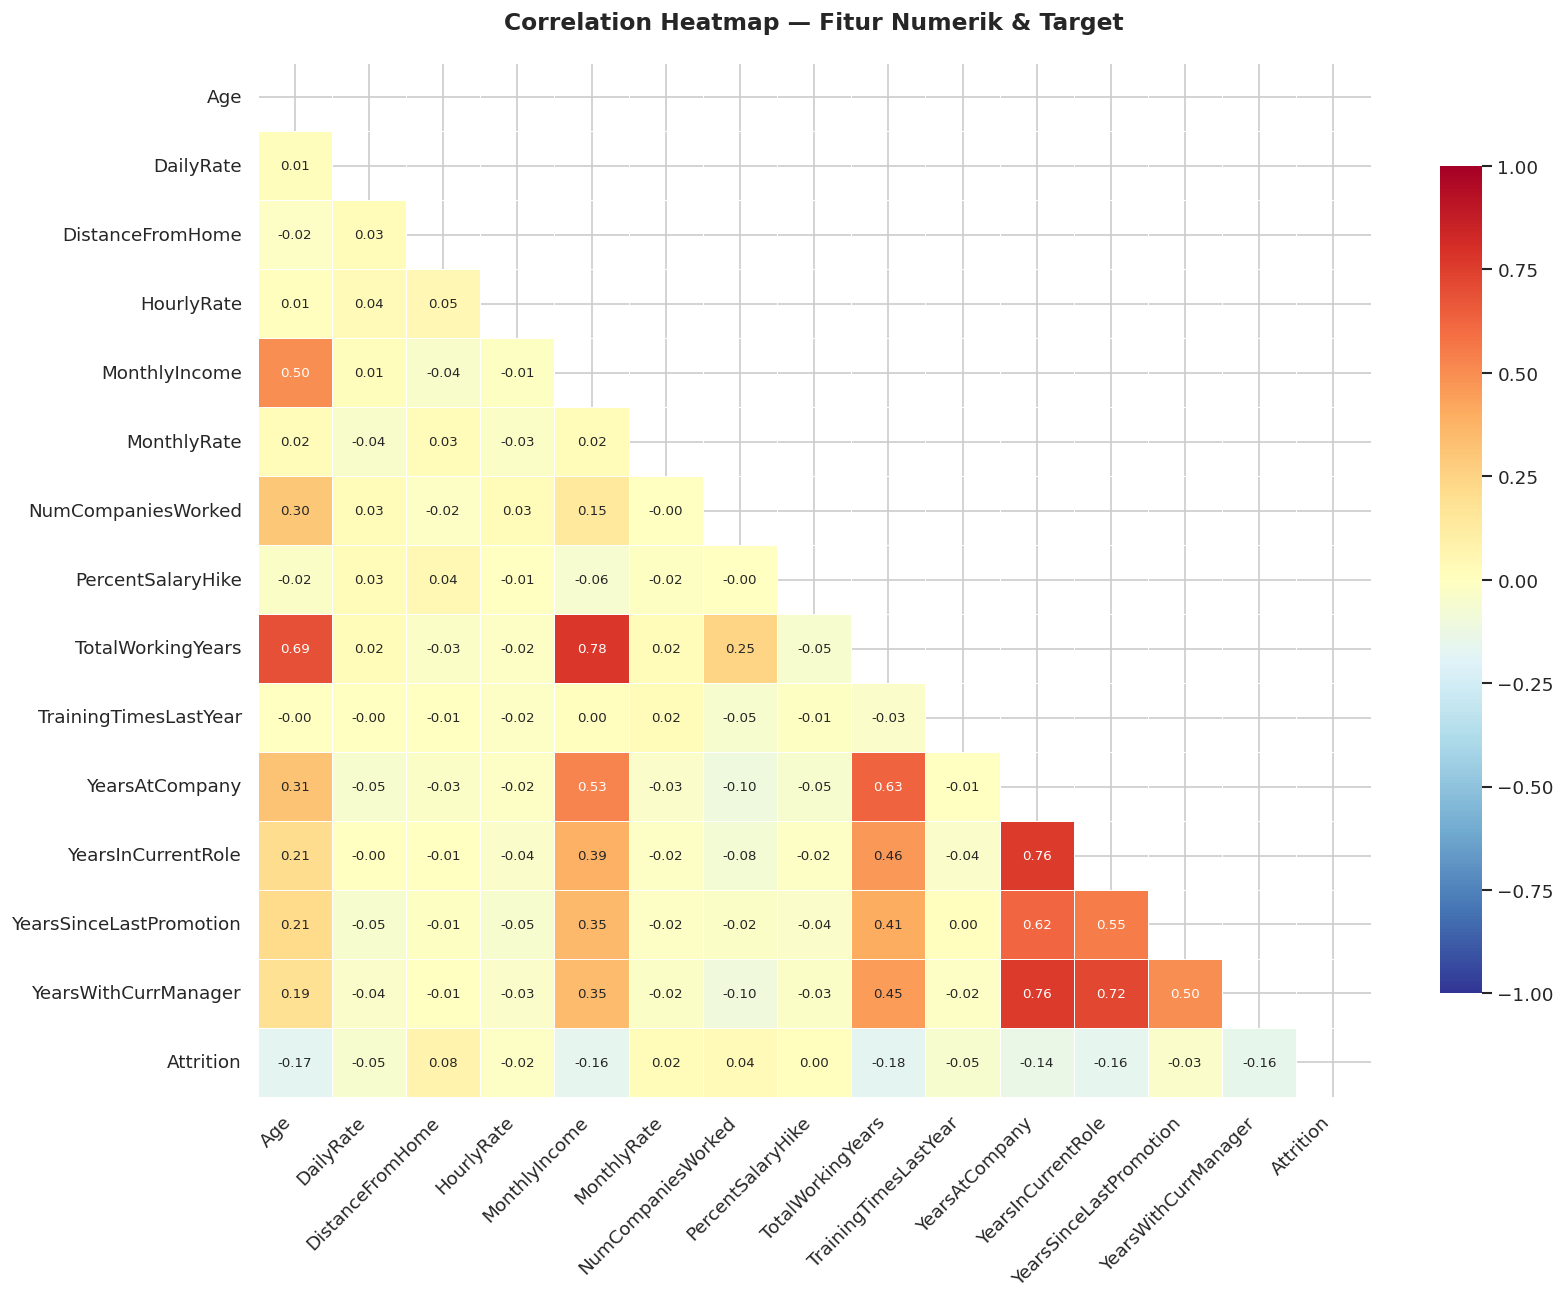

🔗 Top Korelasi dengan Attrition:
---------------------------------------------
   TotalWorkingYears            0.177  (negatif ↓)
   Age                          0.172  (negatif ↓)
   MonthlyIncome                0.164  (negatif ↓)
   YearsInCurrentRole           0.159  (negatif ↓)
   YearsWithCurrManager         0.156  (negatif ↓)
   YearsAtCompany               0.135  (negatif ↓)
   DistanceFromHome             0.078  (positif ↑)
   DailyRate                    0.052  (negatif ↓)
   TrainingTimesLastYear        0.048  (negatif ↓)
   NumCompaniesWorked           0.037  (positif ↑)


In [ ]:
# ============================================================
# Korelasi antar fitur numerik & target
# ============================================================

df_corr = df_labeled.copy()
corr_matrix = df_corr[numeric_cols + ['Attrition']].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 8},
    cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Heatmap — Fitur Numerik & Target',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Top korelasi dengan Attrition
print("🔗 Top Korelasi dengan Attrition:")
print("-" * 45)
corr_target = corr_matrix['Attrition'].drop('Attrition').abs().sort_values(ascending=False)
corr_raw    = corr_matrix['Attrition'].drop('Attrition')
for feat in corr_target.head(10).index:
    val = corr_target[feat]
    dir = "negatif ↓" if corr_raw[feat] < 0 else "positif ↑"
    print(f"   {feat:<28} {val:.3f}  ({dir})")

**Insight Korelasi Antar Fitur**

*   **Korelasi dengan Attrition:**
    *   **Korelasi Negatif Kuat:** `TotalWorkingYears`, `Age`, `MonthlyIncome`, `YearsInCurrentRole`, `YearsWithCurrManager`, `YearsAtCompany` menunjukkan korelasi negatif yang paling kuat dengan *Attrition*. Ini berarti semakin tinggi nilai fitur-fitur ini, semakin kecil kemungkinan karyawan untuk *resign* (yaitu, karyawan yang lebih tua, berpengalaman, bergaji tinggi, dan memiliki *tenure* yang lebih lama cenderung tetap).
    *   **Korelasi Positif Lemah:** `DistanceFromHome` dan `NumCompaniesWorked` menunjukkan korelasi positif yang lemah, artinya karyawan yang tinggal lebih jauh atau pernah bekerja di lebih banyak perusahaan mungkin sedikit lebih cenderung *resign*.

*   **Korelasi Antar Fitur Numerik:**
    *   Ditemukan korelasi positif yang sangat kuat antara `Age` dengan `TotalWorkingYears`, `MonthlyIncome`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsSinceLastPromotion`, dan `YearsWithCurrManager`. Ini masuk akal secara bisnis karena usia biasanya berkorelasi dengan pengalaman dan *tenure*.
    *   `MonthlyIncome` juga sangat berkorelasi positif dengan `JobLevel` (tidak termasuk dalam heatmap ini, tapi logis) dan `TotalWorkingYears`.

**Insight:** Korelasi ini mengonfirmasi temuan dari analisis distribusi sebelumnya. Variabel-variabel yang menunjukkan korelasi negatif kuat dengan *Attrition* (seperti usia dan *tenure*) adalah faktor protektif terhadap *attrition*. Korelasi antar fitur juga mengindikasikan potensi adanya *multicollinearity*, namun untuk model berbasis pohon (seperti Random Forest dan XGBoost), ini umumnya bukan masalah besar.

### Ringkasan Data Understanding



Setelah melakukan pemeriksaan awal, dataset ini memiliki 1,470 baris dan 35 kolom. Target variabel 'Attrition' memiliki 412 missing values (28.0%), yang mengindikasikan bahwa sebagian data tidak berlabel dan perlu dipisahkan untuk prediksi. Terdapat 3 kolom konstan ('EmployeeCount', 'Over18', 'StandardHours') yang tidak memberikan informasi variasi dan akan di-drop. Tidak ditemukan duplikasi data, sehingga integritas data terjamin.

Tahap *Data Understanding* telah berhasil memberikan gambaran menyeluruh mengenai dataset karyawan. Kita telah mengidentifikasi struktur data, tipe data, distribusi fitur numerik dan kategorikal, keberadaan *missing values* (hanya pada target 'Attrition'), tidak adanya duplikasi, serta pola-pola awal yang memengaruhi *attrition*.

**Poin-poin Penting:**
*   **Imbalanced Dataset:** Variabel target `Attrition` sangat tidak seimbang (16.9% Resign), memerlukan penanganan khusus (SMOTE).
*   **Faktor Potensial Attrition:** Usia muda, pendapatan bulanan rendah, masa kerja singkat, sering lembur, status lajang, dan peran pekerjaan tertentu teridentifikasi sebagai faktor risiko utama.
*   **Kolom Tidak Informatif:** `EmployeeId`, `EmployeeCount`, `Over18`, `StandardHours` perlu di-drop.
*   **Outlier:** Beberapa fitur numerik memiliki *outlier*, yang perlu diingat saat memilih dan melatih model.
*   **Korelasi:** Fitur seperti `Age`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany` memiliki korelasi negatif yang kuat dengan *Attrition*.

Wawasan ini menjadi dasar kuat untuk melanjutkan ke tahap *Data Preparation* dan *Modeling* dengan strategi yang tepat.

## Data Preparation

### Drop Kolom Konstan dan Identifier

In [ ]:
# ============================================================
# Setup ulang variabel & buat salinan dataset awal
# ============================================================

# Buat salinan dari dataset yang sudah dimuat sebelumnya

df_raw = df.copy()

print(f"✅ Variabel global disiapkan dan df_raw dibuat dari df ({df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom)")

✅ Variabel global disiapkan dan df_raw dibuat dari df (1,470 baris × 35 kolom)


In [ ]:
# ============================================================
# Drop kolom konstan dan identifier
# ============================================================

# Kolom yang di-drop beserta alasannya
DROP_COLS = {
    'EmployeeId'    : 'Identifier unik — tidak memiliki nilai prediktif',
    'EmployeeCount' : 'Konstan (semua nilai = 1)',
    'Over18'        : 'Konstan (semua nilai = Y)',
    'StandardHours' : 'Konstan (semua nilai = 80)',
}

print("=" * 60)
print("  STEP 1 — DROP KOLOM TIDAK INFORMATIF")
print("=" * 60)
print(f"\nKolom yang di-drop ({len(DROP_COLS)}):")
for col, reason in DROP_COLS.items():
    print(f"  ✗  {col:<20} → {reason}")

# Eksekusi drop
df = df_raw.drop(columns=list(DROP_COLS.keys()))

print(f"\nShape sebelum : {df_raw.shape[0]:,} × {df_raw.shape[1]}")
print(f"Shape sesudah : {df.shape[0]:,} × {df.shape[1]}")
print(f"\n✅ Sisa kolom  : {df.shape[1]} kolom")
print(df.columns.tolist())

  STEP 1 — DROP KOLOM TIDAK INFORMATIF

Kolom yang di-drop (4):
  ✗  EmployeeId           → Identifier unik — tidak memiliki nilai prediktif
  ✗  EmployeeCount        → Konstan (semua nilai = 1)
  ✗  Over18               → Konstan (semua nilai = Y)
  ✗  StandardHours        → Konstan (semua nilai = 80)

Shape sebelum : 1,470 × 35
Shape sesudah : 1,470 × 31

✅ Sisa kolom  : 31 kolom
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


**Insight Drop Kolom Konstan dan Identifier**

Penghapusan kolom `EmployeeId`, `EmployeeCount`, `Over18`, dan `StandardHours` adalah langkah penting karena kolom-kolom ini tidak memberikan informasi variasi atau bersifat unik sebagai identitas. Mereka tidak memiliki nilai prediktif dan justru dapat menambah kompleksitas komputasi tanpa manfaat. Dengan menghapusnya, kita mengurangi dimensi dataset dan fokus pada fitur-fitur yang relevan.

### Pemisahan Labeled & Unlabeled

In [ ]:
# ============================================================
# Pisahkan labeled (untuk training) & unlabeled (untuk prediksi)
# ============================================================

print("=" * 60)
print("  STEP 2 — PISAHKAN LABELED & UNLABELED DATA")
print("=" * 60)

# Data berlabel → untuk training & evaluasi model
df_labeled   = df.dropna(subset=['Attrition']).copy()
df_labeled['Attrition'] = df_labeled['Attrition'].astype(int)

# Data unlabeled → untuk prediksi nanti (setelah model jadi)
df_unlabeled = df[df['Attrition'].isna()].copy()
df_unlabeled = df_unlabeled.drop(columns=['Attrition'])

attrition_counts = df_labeled['Attrition'].value_counts()
attrition_rate   = df_labeled['Attrition'].mean() * 100

print(f"\n📋 Data berlabel   : {len(df_labeled):,} baris")
print(f"   - Stay  (0)    : {attrition_counts[0]:,} ({attrition_counts[0]/len(df_labeled)*100:.1f}%)")
print(f"   - Resign (1)   : {attrition_counts[1]:,} ({attrition_counts[1]/len(df_labeled)*100:.1f}%)")
print(f"   - Attrition rate: {attrition_rate:.1f}%")
print(f"\n📋 Data unlabeled  : {len(df_unlabeled):,} baris (akan diprediksi setelah modeling)")

# Simpan unlabeled untuk nanti
df_unlabeled_backup = df_unlabeled.copy()
print(f"\n✅ df_labeled   → {df_labeled.shape}")
print(f"✅ df_unlabeled → {df_unlabeled.shape}")

  STEP 2 — PISAHKAN LABELED & UNLABELED DATA

📋 Data berlabel   : 1,058 baris
   - Stay  (0)    : 879 (83.1%)
   - Resign (1)   : 179 (16.9%)
   - Attrition rate: 16.9%

📋 Data unlabeled  : 412 baris (akan diprediksi setelah modeling)

✅ df_labeled   → (1058, 31)
✅ df_unlabeled → (412, 30)


**Insight Pemisahan Labeled & Unlabeled Data**

Pemisahan dataset menjadi `df_labeled` dan `df_unlabeled` sangat krusial. `df_labeled` (yang memiliki nilai 'Attrition') akan menjadi dasar untuk melatih dan mengevaluasi model. Sedangkan `df_unlabeled` (yang kolom 'Attrition'-nya kosong) akan digunakan kemudian untuk memprediksi karyawan mana yang berpotensi *resign* setelah model terbaik ditemukan. Pendekatan ini memastikan bahwa evaluasi model dilakukan secara adil pada data yang sudah memiliki label aktual, dan prediksi pada data baru tidak bias oleh informasi target yang tidak ada.

### Encoding Fitur Kategorikal

In [ ]:
# ============================================================
# Encoding fitur kategorikal → numerik
# ============================================================

print("=" * 60)
print("  STEP 3 — ENCODING FITUR KATEGORIKAL")
print("=" * 60)

# Pisahkan fitur dan target
X = df_labeled.drop(columns=['Attrition'])
y = df_labeled['Attrition']

# Identifikasi kolom kategorikal
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f"\nKolom yang di-encode ({len(cat_cols)}):")

# Strategi encoding:
# - Binary (2 kategori)  → Label Encoding (lebih efisien)
# - Nominal (3+ kategori) → One-Hot Encoding (hindari ordinal assumption)

binary_cols  = [c for c in cat_cols if X[c].nunique() == 2]
nominal_cols = [c for c in cat_cols if X[c].nunique() > 2]

print(f"\n  Label Encoding (binary, 2 kategori) — {len(binary_cols)} kolom:")
for col in binary_cols:
    print(f"    {col}: {X[col].unique().tolist()}")

print(f"\n  One-Hot Encoding (nominal, 3+ kategori) — {len(nominal_cols)} kolom:")
for col in nominal_cols:
    print(f"    {col}: {X[col].nunique()} kategori → {X[col].unique().tolist()}")

# --- Label Encoding untuk kolom binary ---
le_dict = {}
for col in binary_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"\n  ✅ {col}: {mapping}")

# --- One-Hot Encoding untuk kolom nominal ---
X = pd.get_dummies(X, columns=nominal_cols, drop_first=False)

# Juga encode unlabeled data dengan cara yang sama
X_unlabeled = df_unlabeled.copy()
for col in binary_cols:
    X_unlabeled[col] = le_dict[col].transform(X_unlabeled[col])
X_unlabeled = pd.get_dummies(X_unlabeled, columns=nominal_cols, drop_first=False)

# Align kolom agar sama persis dengan X (training)
X_unlabeled = X_unlabeled.reindex(columns=X.columns, fill_value=0)

print(f"\n✅ Shape X setelah encoding : {X.shape}")
print(f"✅ Shape X_unlabeled        : {X_unlabeled.shape}")
print(f"\nDaftar kolom setelah encoding ({X.shape[1]}):")
print(X.columns.tolist())

  STEP 3 — ENCODING FITUR KATEGORIKAL

Kolom yang di-encode (7):

  Label Encoding (binary, 2 kategori) — 2 kolom:
    Gender: ['Female', 'Male']
    OverTime: ['No', 'Yes']

  One-Hot Encoding (nominal, 3+ kategori) — 5 kolom:
    BusinessTravel: 3 kategori → ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
    Department: 3 kategori → ['Research & Development', 'Sales', 'Human Resources']
    EducationField: 6 kategori → ['Medical', 'Life Sciences', 'Marketing', 'Technical Degree', 'Human Resources', 'Other']
    JobRole: 9 kategori → ['Healthcare Representative', 'Research Scientist', 'Sales Executive', 'Manager', 'Laboratory Technician', 'Research Director', 'Manufacturing Director', 'Human Resources', 'Sales Representative']
    MaritalStatus: 3 kategori → ['Married', 'Single', 'Divorced']

  ✅ Gender: {'Female': np.int64(0), 'Male': np.int64(1)}

  ✅ OverTime: {'No': np.int64(0), 'Yes': np.int64(1)}

✅ Shape X setelah encoding : (1058, 49)
✅ Shape X_unlabeled        : (412, 4

**Insight Encoding Fitur Kategorikal**

Transformasi fitur kategorikal menjadi numerik sangat diperlukan karena sebagian besar algoritma Machine Learning hanya dapat memproses data numerik. Penggunaan `Label Encoding` untuk fitur biner (`Gender`, `OverTime`) dan `One-Hot Encoding` untuk fitur nominal multi-kategori (`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`) adalah pilihan yang tepat. Label Encoding lebih efisien untuk biner, sementara One-Hot Encoding mencegah model mengasumsikan hubungan ordinal (peringkat) yang tidak ada pada fitur nominal, menjaga akurasi interpretasi model.

### Validasi Hasil Encoding

In [ ]:
# ============================================================
# Validasi hasil encoding — pastikan tidak ada nilai non-numerik
# ============================================================

print("=" * 60)
print("  VALIDASI ENCODING")
print("=" * 60)

# Convert boolean columns created by get_dummies to int to ensure all are explicitly numeric
# and avoid misleading 'non-numeric' warnings for boolean columns.
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
for col in X_unlabeled.select_dtypes(include='bool').columns:
    X_unlabeled[col] = X_unlabeled[col].astype(int)

# Cek tipe data
non_numeric = X.select_dtypes(exclude=['number']).columns.tolist()
if len(non_numeric) == 0:
    print("\n✅ Semua kolom sudah bertipe numerik!")
else:
    print(f"\n❌ Masih ada kolom non-numerik: {non_numeric}")

# Cek missing values
missing = X.isnull().sum().sum()
if missing == 0:
    print("✅ Tidak ada missing values di X!")
else:
    print(f"❌ Masih ada {missing} missing values!")

# Tampilkan 5 baris pertama hasil encoding
print(f"\n📋 Preview X setelah encoding (5 baris):")
display(X.head())

print(f"\n📋 Distribusi target y:")
print(y.value_counts())
print(f"   Attrition rate: {y.mean()*100:.1f}%")

  VALIDASI ENCODING

✅ Semua kolom sudah bertipe numerik!
✅ Tidak ada missing values di X!

📋 Preview X setelah encoding (5 baris):


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Non-Travel,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,JobRole_Healthcare Representative,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
1,37,1141,11,2,1,0,61,1,2,2,4777,14382,5,0,15,3,1,0,15,2,1,1,0,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0
2,51,1323,4,4,1,1,34,3,1,3,2461,10332,9,1,12,3,3,3,18,2,4,10,0,2,7,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0
3,42,555,26,3,3,0,77,3,4,2,13525,14864,5,0,14,3,4,1,23,2,4,20,4,4,8,0,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
6,40,1124,1,2,2,1,57,1,2,4,7457,13273,2,1,22,4,3,3,6,2,2,4,3,0,2,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1,0
7,55,725,2,3,4,1,78,3,5,1,19859,21199,5,1,13,3,4,1,24,2,3,5,2,1,4,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0



📋 Distribusi target y:
Attrition
0    879
1    179
Name: count, dtype: int64
   Attrition rate: 16.9%


**Insight Validasi Hasil Encoding**

Validasi setelah encoding memastikan bahwa semua fitur telah berhasil diubah menjadi tipe numerik dan tidak ada *missing values* yang baru muncul selama proses transformasi. Langkah ini penting untuk mencegah eror pada tahap modeling dan memastikan integritas data. Pemeriksaan ini menjamin bahwa data siap untuk langkah selanjutnya tanpa masalah tipe data atau kekosongan nilai.

### Split Data

  STEP 4 — TRAIN-TEST SPLIT (80:20, Stratified)

  Train set : 846 baris (80%)
  Test set  : 212 baris (20%)

  Attrition rate Train : 16.9%
  Attrition rate Test  : 17.0%
  ✅ Proporsi terjaga (stratify=y berhasil)


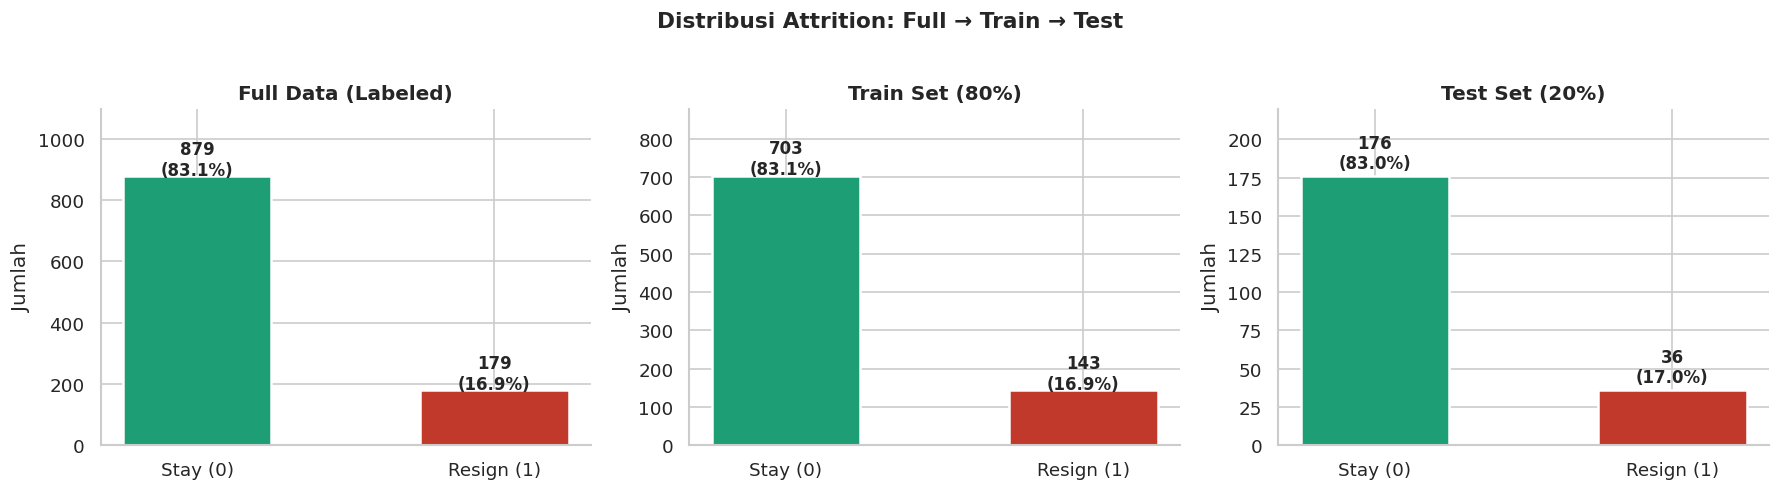

In [ ]:
# ============================================================
# Split data → Training set (80%) & Test set (20%)
# ============================================================

print("=" * 60)
print("  STEP 4 — TRAIN-TEST SPLIT (80:20, Stratified)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = RANDOM_STATE,
    stratify     = y        # Penting: jaga proporsi Attrition di train & test
)

print(f"\n  Train set : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test set  : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verifikasi stratifikasi
train_rate = y_train.mean() * 100
test_rate  = y_test.mean()  * 100
print(f"\n  Attrition rate Train : {train_rate:.1f}%")
print(f"  Attrition rate Test  : {test_rate:.1f}%")
print(f"  ✅ Proporsi terjaga (stratify=y berhasil)")

# Visualisasi split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, y_data) in zip(axes, [
    ('Full Data (Labeled)', y),
    ('Train Set (80%)', y_train),
    ('Test Set (20%)',  y_test),
]):
    counts = y_data.value_counts()
    pcts   = y_data.value_counts(normalize=True) * 100
    bars   = ax.bar(['Stay (0)', 'Resign (1)'], counts.values,
                    color=PALETTE_ATTRITION, edgecolor='white', linewidth=1.5, width=0.5)
    for bar, count, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', fontsize=10, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Jumlah')
    ax.set_ylim(0, counts.max() * 1.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Distribusi Attrition: Full → Train → Test",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight Train-Test Split**

Pembagian data menjadi *training set* (80%) dan *test set* (20%) dengan strategi `stratify=y` adalah praktik terbaik untuk evaluasi model yang realistis, terutama pada *imbalanced dataset*. Stratifikasi memastikan bahwa proporsi kelas 'Resign' dan 'Stay' terjaga di kedua set, sehingga model tidak hanya belajar dari kelas mayoritas. Ini mencegah *over-optimistic evaluation* dan memberikan gambaran performa model yang lebih akurat pada data baru.

### SMOTE

  STEP 5 — HANDLING IMBALANCE DENGAN SMOTE

  Sebelum SMOTE (Train set):
  Stay   (0) : 703
  Resign (1) : 143
  Rasio      : 4.9 : 1

  Sesudah SMOTE (Train set):
  Stay   (0) : 703
  Resign (1) : 703
  Rasio      : 1.0 : 1
  Total      : 1,406 baris


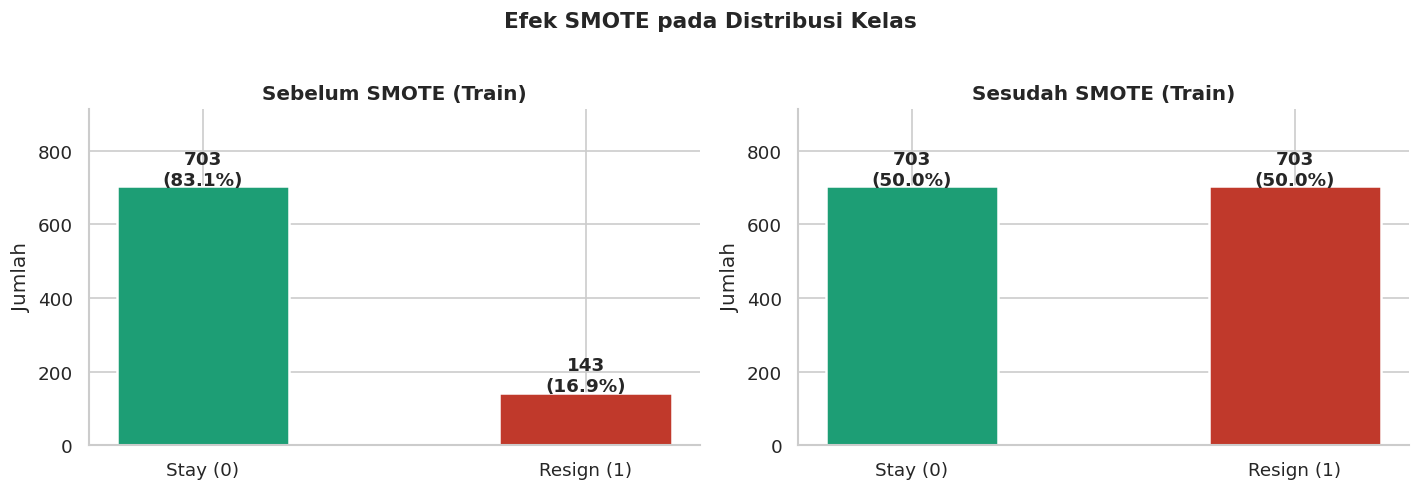


⚠️  Catatan Penting:
   - SMOTE HANYA diterapkan pada X_train & y_train
   - X_test & y_test TIDAK disentuh (evaluasi harus pada data asli)
   - SMOTE membuat synthetic samples pada minority class (Resign)


In [ ]:
# ============================================================
# SMOTE — Synthetic Minority Oversampling Technique
# Hanya diterapkan pada TRAIN SET (bukan test set!)
# ============================================================

print("=" * 60)
print("  STEP 5 — HANDLING IMBALANCE DENGAN SMOTE")
print("=" * 60)

print(f"\n  Sebelum SMOTE (Train set):")
print(f"  Stay   (0) : {(y_train == 0).sum():,}")
print(f"  Resign (1) : {(y_train == 1).sum():,}")
print(f"  Rasio      : {(y_train==0).sum()/(y_train==1).sum():.1f} : 1")

# Terapkan SMOTE hanya pada training data
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"\n  Sesudah SMOTE (Train set):")
print(f"  Stay   (0) : {(y_train_smote == 0).sum():,}")
print(f"  Resign (1) : {(y_train_smote == 1).sum():,}")
print(f"  Rasio      : {(y_train_smote==0).sum()/(y_train_smote==1).sum():.1f} : 1")
print(f"  Total      : {len(X_train_smote):,} baris")

# Visualisasi sebelum vs sesudah SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, y_data) in zip(axes, [
    ('Sebelum SMOTE (Train)', y_train),
    ('Sesudah SMOTE (Train)', y_train_smote),
]):
    counts = pd.Series(y_data).value_counts().sort_index()
    pcts   = counts / counts.sum() * 100
    bars   = ax.bar(['Stay (0)', 'Resign (1)'], counts.values,
                    color=PALETTE_ATTRITION, edgecolor='white', linewidth=1.5, width=0.45)
    for bar, count, pct in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{count:,}\n({pct:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Jumlah')
    ax.set_ylim(0, counts.max() * 1.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("Efek SMOTE pada Distribusi Kelas",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n⚠️  Catatan Penting:")
print("   - SMOTE HANYA diterapkan pada X_train & y_train")
print("   - X_test & y_test TIDAK disentuh (evaluasi harus pada data asli)")
print("   - SMOTE membuat synthetic samples pada minority class (Resign)")

**Insight Penanganan Imbalance dengan SMOTE**

Dataset 'Attrition' sangat tidak seimbang (hanya 16.9% kasus resign), yang dapat menyebabkan model bias dan buruk dalam memprediksi kelas minoritas. `SMOTE` (Synthetic Minority Oversampling Technique) diaplikasikan pada *training set* untuk menghasilkan sampel sintetis dari kelas minoritas ('Resign'), menyeimbangkan rasio kelas menjadi 1:1. Langkah ini memungkinkan model untuk belajar pola dari kelas minoritas secara lebih efektif, sehingga meningkatkan kemampuan model dalam mendeteksi kasus *attrition* yang sebenarnya (meningkatkan *Recall*).

### StandardScaler

In [ ]:
# ============================================================
# StandardScaler — standarisasi fitur numerik
# ============================================================

print("=" * 60)
print("  STEP 6 — FEATURE SCALING (StandardScaler)")
print("=" * 60)

# Identifikasi kolom numerik yang perlu di-scale
# Kolom yang tidak perlu di-scale adalah hasil dari one-hot encoding (binary 0/1)
# dan label encoding binary (Gender, OverTime) karena sudah dalam skala yang sesuai.
ohe_and_binary_encoded_cols = [c for c in X_train.columns if X_train[c].nunique() <= 2 and c != 'Attrition']
# Remove original binary encoded features if they were already handled by LabelEncoder for clarity
original_binary_cols = ['Gender', 'OverTime']
for col in original_binary_cols:
    if col in ohe_and_binary_encoded_cols:
        ohe_and_binary_encoded_cols.remove(col)

# Combine with actual OHE features
ohe_and_binary_encoded_cols.extend([c for c in X_train.columns if '_BusinessTravel_' in c or '_Department_' in c or '_EducationField_' in c or '_JobRole_' in c or '_MaritalStatus_' in c])
# Add the original binary encoded columns back in the specific list
ohe_and_binary_encoded_cols.extend(original_binary_cols)

# Ensure unique and sorted for consistency
ohe_and_binary_encoded_cols = sorted(list(set(ohe_and_binary_encoded_cols)))

numeric_cols = [c for c in X_train.columns if c not in ohe_and_binary_encoded_cols]

print(f"\n  Kolom yang di-scale ({len(numeric_cols)}):")
for c in numeric_cols:
    print(f"    - {c}")

print(f"\n  Kolom yang TIDAK di-scale (OHE/binary) ({len(ohe_and_binary_encoded_cols)}):")
for c in ohe_and_binary_encoded_cols:
    print(f"    - {c}")

# Fit scaler HANYA pada training data, transform pada semua set
scaler = StandardScaler()

# Buat salinan agar X asli tetap tersimpan
X_train_scaled = X_train_smote.copy()
X_test_scaled  = X_test.copy()
X_unlab_scaled = X_unlabeled.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train_smote[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])
X_unlab_scaled[numeric_cols] = scaler.transform(X_unlabeled[numeric_cols])

print(f"\n✅ Scaler di-fit pada: X_train_smote ({X_train_smote.shape[0]:,} baris)")
print(f"✅ Transform diterapkan pada:")
print(f"   - X_train_scaled : {X_train_scaled.shape}")
print(f"   - X_test_scaled  : {X_test_scaled.shape}")
print(f"   - X_unlab_scaled : {X_unlab_scaled.shape}")

# Verifikasi hasil scaling
print(f"\n  Statistik X_train_scaled (kolom numerik pertama):")
print(X_train_scaled[numeric_cols[:5]].describe().round(3).to_string())

  STEP 6 — FEATURE SCALING (StandardScaler)

  Kolom yang di-scale (22):
    - Age
    - DailyRate
    - DistanceFromHome
    - Education
    - EnvironmentSatisfaction
    - HourlyRate
    - JobInvolvement
    - JobLevel
    - JobSatisfaction
    - MonthlyIncome
    - MonthlyRate
    - NumCompaniesWorked
    - PercentSalaryHike
    - RelationshipSatisfaction
    - StockOptionLevel
    - TotalWorkingYears
    - TrainingTimesLastYear
    - WorkLifeBalance
    - YearsAtCompany
    - YearsInCurrentRole
    - YearsSinceLastPromotion
    - YearsWithCurrManager

  Kolom yang TIDAK di-scale (OHE/binary) (27):
    - BusinessTravel_Non-Travel
    - BusinessTravel_Travel_Frequently
    - BusinessTravel_Travel_Rarely
    - Department_Human Resources
    - Department_Research & Development
    - Department_Sales
    - EducationField_Human Resources
    - EducationField_Life Sciences
    - EducationField_Marketing
    - EducationField_Medical
    - EducationField_Other
    - EducationField_Technical

**Insight Feature Scaling dengan StandardScaler**

`StandardScaler` mengubah distribusi fitur numerik sehingga memiliki rata-rata nol dan standar deviasi satu (z-score). Ini krusial untuk algoritma Machine Learning yang sensitif terhadap skala fitur, seperti `Logistic Regression` atau model berbasis jarak, karena membantu mereka konvergen lebih cepat dan menghindari dominasi fitur dengan rentang nilai yang besar. Penting untuk melakukan *fit* `StandardScaler` hanya pada *training set* (setelah SMOTE) dan kemudian menerapkannya (`transform`) pada *training*, *test*, dan *unlabeled set* untuk menghindari *data leakage*.

### Visualisasi Distribusi

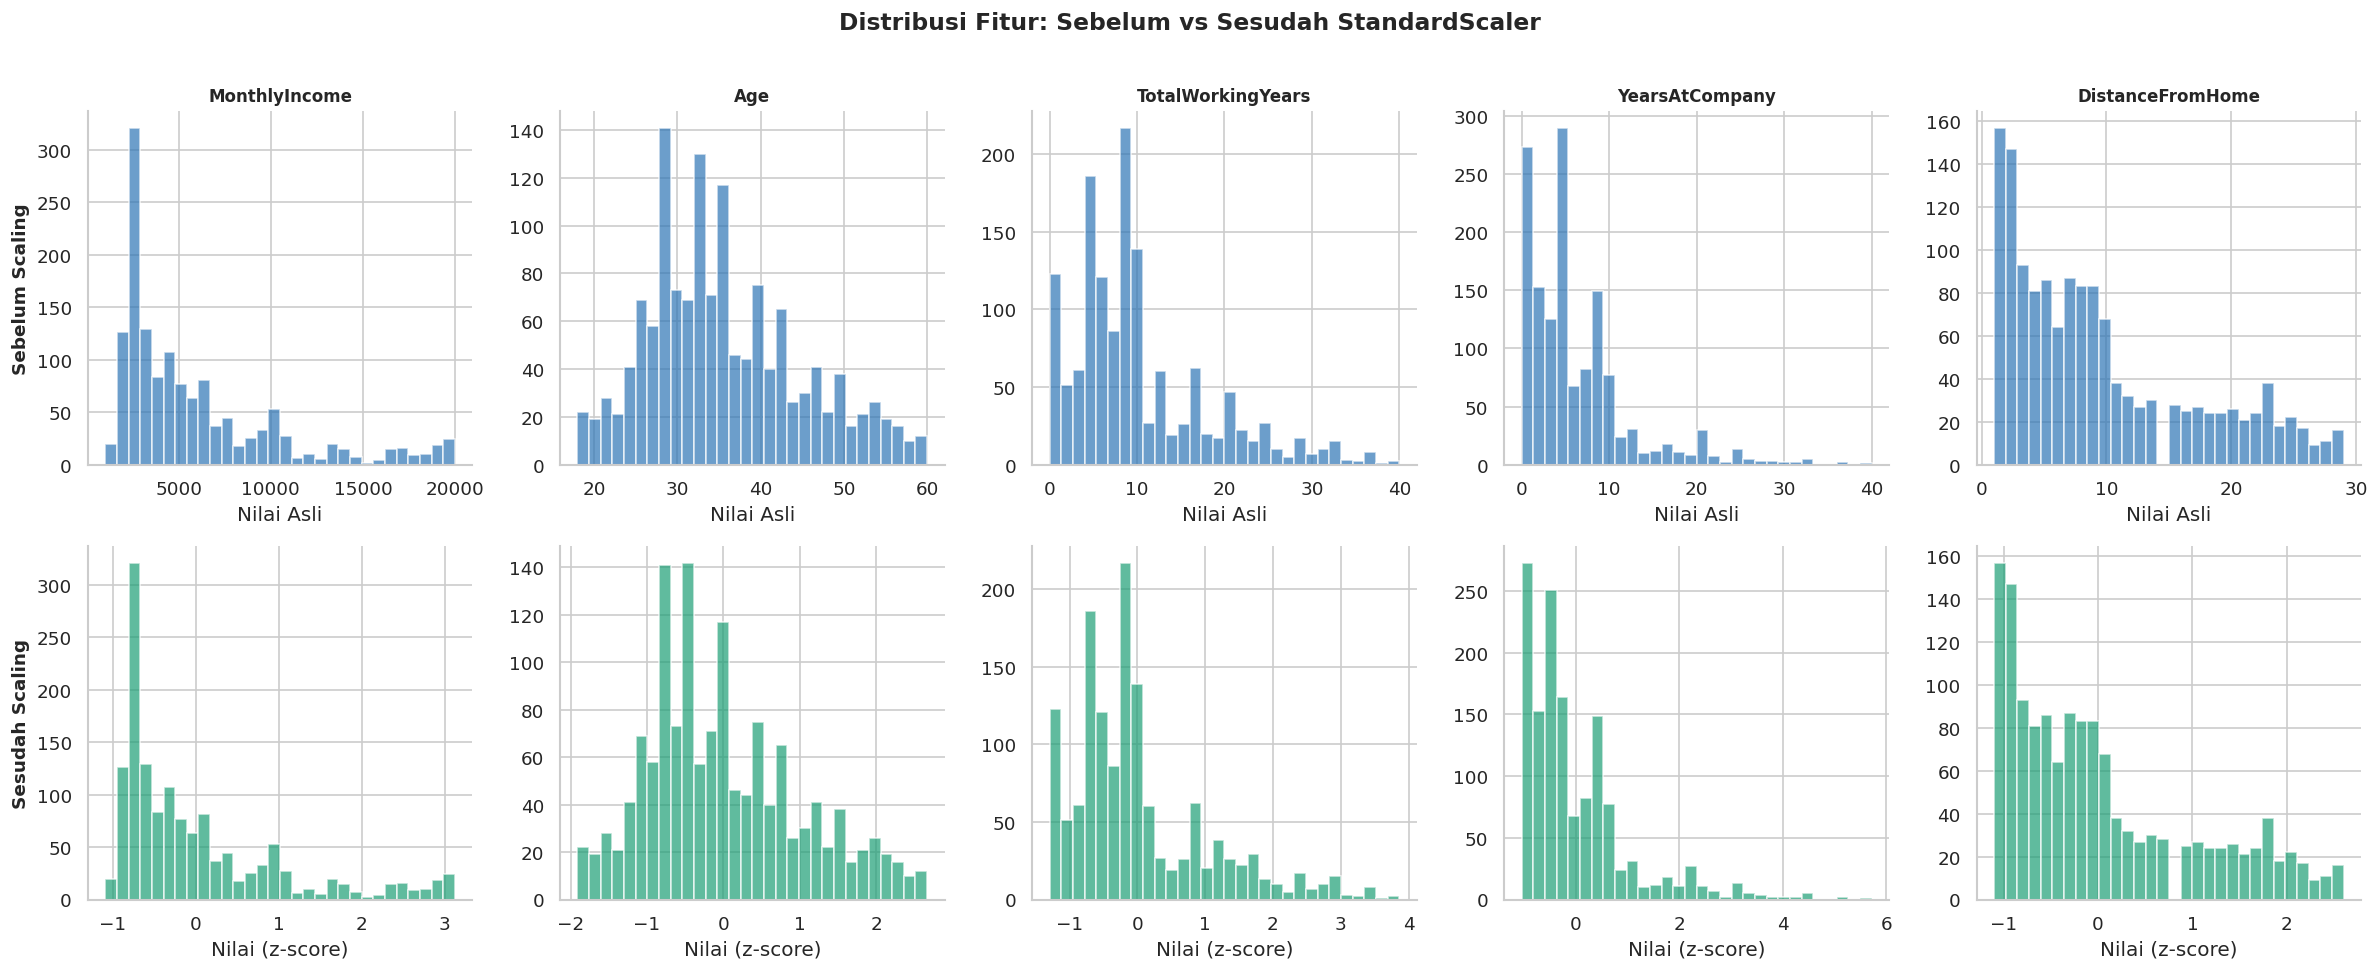

📌 Catatan:
   StandardScaler: z = (x - mean) / std
   Semua fitur numerik kini memiliki mean ≈ 0 dan std ≈ 1
   Penting untuk model berbasis jarak & gradient (Logistic Regression)


In [ ]:
# ============================================================
# CELL 9: Visualisasi distribusi sebelum vs sesudah scaling
# ============================================================

cols_viz = ['MonthlyIncome', 'Age', 'TotalWorkingYears',
            'YearsAtCompany', 'DistanceFromHome']

fig, axes = plt.subplots(2, len(cols_viz), figsize=(20, 8))

for i, col in enumerate(cols_viz):
    # Sebelum scaling
    axes[0, i].hist(X_train_smote[col], bins=30,
                    color=COLORS['primary'], alpha=0.7, edgecolor='white')
    axes[0, i].set_title(col, fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel('Nilai Asli')
    if i == 0:
        axes[0, i].set_ylabel('Sebelum Scaling', fontsize=11, fontweight='bold')
    axes[0, i].spines['top'].set_visible(False)
    axes[0, i].spines['right'].set_visible(False)

    # Sesudah scaling
    axes[1, i].hist(X_train_scaled[col], bins=30,
                    color=COLORS['success'], alpha=0.7, edgecolor='white')
    axes[1, i].set_xlabel('Nilai (z-score)')
    if i == 0:
        axes[1, i].set_ylabel('Sesudah Scaling', fontsize=11, fontweight='bold')
    axes[1, i].spines['top'].set_visible(False)
    axes[1, i].spines['right'].set_visible(False)

plt.suptitle("Distribusi Fitur: Sebelum vs Sesudah StandardScaler",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("📌 Catatan:")
print("   StandardScaler: z = (x - mean) / std")
print("   Semua fitur numerik kini memiliki mean ≈ 0 dan std ≈ 1")
print("   Penting untuk model berbasis jarak & gradient (Logistic Regression)")

**Insight Visualisasi Distribusi Sebelum dan Sesudah Scaling**

Visualisasi distribusi fitur sebelum dan sesudah *scaling* menegaskan bahwa proses *standardization* telah berhasil mengubah skala fitur tanpa mengubah bentuk distribusinya. Ini memberikan konfirmasi visual bahwa *feature scaling* telah diterapkan dengan benar, yang penting untuk model yang akan dilatih.

### Penyimpanan Semua Objek Preprocessing

In [ ]:
# ============================================================
# Simpan semua objek preprocessing untuk digunakan ulang
# ============================================================

import pickle

preprocessing_artifacts = {
    'label_encoders' : le_dict,
    'scaler'         : scaler,
    'feature_columns': list(X.columns),
    'numeric_cols'   : numeric_cols,
    'ohe_cols'       : ohe_and_binary_encoded_cols,
}

with open('preprocessing_artifacts.pkl', 'wb') as f:
    pickle.dump(preprocessing_artifacts, f)

print("✅ Preprocessing artifacts tersimpan di 'preprocessing_artifacts.pkl'")
print("   Isi:")
for key in preprocessing_artifacts:
    val = preprocessing_artifacts[key]
    if isinstance(val, list):
        print(f"   - {key}: {len(val)} item")
    else:
        print(f"   - {key}: {type(val).__name__}")

✅ Preprocessing artifacts tersimpan di 'preprocessing_artifacts.pkl'
   Isi:
   - label_encoders: dict
   - scaler: StandardScaler
   - feature_columns: 49 item
   - numeric_cols: 22 item
   - ohe_cols: 27 item


**Insight Penyimpanan Objek Preprocessing**

Penyimpanan `preprocessing_artifacts` (seperti *label encoders* dan *scaler*) adalah praktik terbaik dalam siklus hidup proyek Machine Learning. Ini memungkinkan reproduksibilitas penuh dan konsistensi dalam memproses data baru di masa depan. Ketika model di-deploy atau digunakan untuk prediksi data baru, data tersebut harus melewati langkah-langkah *preprocessing* yang sama persis seperti data pelatihan untuk memastikan hasil prediksi yang akurat dan dapat diandalkan.

### Ringkasan Data Preparation

Tahap *Data Preparation* telah dilakukan dengan seksama untuk mengubah data mentah menjadi format yang siap untuk *modeling*. Berikut adalah ringkasan langkah-langkah yang diambil:

1.  **Drop Kolom Tidak Informatif:** Kolom `EmployeeId`, `EmployeeCount`, `Over18`, dan `StandardHours` yang bersifat konstan atau *identifier* telah dihapus dari dataset karena tidak memberikan nilai prediktif.
2.  **Pemisahan Labeled & Unlabeled Data:** Data dibagi menjadi `df_labeled` (1,058 baris dengan target 'Attrition' yang valid) untuk *training* dan *testing*, serta `df_unlabeled` (412 baris tanpa target 'Attrition') yang akan digunakan untuk prediksi di akhir proses.
3.  **Encoding Fitur Kategorikal:** Semua fitur kategorikal telah diubah menjadi numerik:
    *   **Label Encoding:** Untuk kolom biner (`Gender`, `OverTime`), mengubah 'Yes'/'No' atau 'Male'/'Female' menjadi 0/1.
    *   **One-Hot Encoding:** Untuk kolom nominal dengan lebih dari 2 kategori (`BusinessTravel`, `Department`, `EducationField`, `JobRole`, `MaritalStatus`), untuk menghindari asumsi ordinalitas.
4.  **Validasi Encoding:** Memastikan semua kolom sudah numerik dan tidak ada *missing values* setelah encoding.
5.  **Train-Test Split:** Data berlabel (`X`, `y`) dibagi menjadi *training set* (80%) dan *test set* (20%) menggunakan `stratify=y` untuk menjaga proporsi kelas `Attrition` di kedua set, yang sangat penting mengingat *imbalanced dataset*.
6.  **SMOTE (Synthetic Minority Oversampling Technique):** Diterapkan pada `X_train` dan `y_train` untuk menyeimbangkan distribusi kelas. Setelah SMOTE, rasio kelas `Stay` dan `Resign` pada *training set* menjadi 1:1, mengurangi bias model terhadap kelas mayoritas.
7.  **StandardScaler:** Fitur-fitur numerik yang tidak biner diskalakan menggunakan StandardScaler. Ini penting untuk model yang sensitif terhadap skala fitur (misalnya, Logistic Regression) agar konvergensi lebih cepat dan performa lebih baik. *Scaler* di-fit hanya pada *training set* (setelah SMOTE) dan diterapkan pada semua set data (train, test, unlabeled).
8.  **Penyimpanan Artifacts Preprocessing:** Objek-objek penting seperti *LabelEncoder* dan *StandardScaler* disimpan (`preprocessing_artifacts.pkl`) agar dapat digunakan kembali untuk memproses data baru di masa mendatang.

**Kesimpulan Tahap Data Preparation:** Data kini sudah bersih, terstruktur, seimbang, dan diskalakan, siap untuk dimasukkan ke dalam model *machine learning*.

## Modeling

### Definisikan Model

In [ ]:
# ============================================================
# Definisi semua model yang akan dibandingkan
# ============================================================

print("=" * 60)
print("  MODEL YANG AKAN DIBANDINGKAN")
print("=" * 60)

models = {
    'Logistic Regression' : LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        class_weight='balanced'
    ),
    'Decision Tree' : DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ),
    'Random Forest' : RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        class_weight='balanced'
    ),
    'XGBoost' : XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric='logloss',
        verbosity=0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum()
    ),
}

desc = {
    'Logistic Regression' : 'Linear, interpretable, cocok sebagai baseline',
    'Decision Tree'       : 'Tree-based, mudah divisualisasi, rentan overfit',
    'Random Forest'       : 'Ensemble bagging, robust, dilengkapi feature importance',
    'XGBoost'             : 'Ensemble boosting, state-of-the-art tabular data',
}

print(f"\n  {'Model':<25} {'Keterangan'}")
print("  " + "-" * 70)
for name, info in desc.items():
    print(f"  {name:<25} {info}")

print(f"\n  {len(models)} model siap dilatih")

  MODEL YANG AKAN DIBANDINGKAN

  Model                     Keterangan
  ----------------------------------------------------------------------
  Logistic Regression       Linear, interpretable, cocok sebagai baseline
  Decision Tree             Tree-based, mudah divisualisasi, rentan overfit
  Random Forest             Ensemble bagging, robust, dilengkapi feature importance
  XGBoost                   Ensemble boosting, state-of-the-art tabular data

  4 model siap dilatih


### Latih Semua Model

In [ ]:
# ============================================================
# Latih semua model dan bandingkan performa di test set
# ============================================================

print("=" * 60)
print("  BASELINE TRAINING")
print("=" * 60)

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_smote)

    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
        'accuracy' : accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_test, y_prob),
    }
    print(f"  Selesai: {name}")

# Tabel perbandingan
print("\n" + "=" * 75)
print(f"  {'Model':<25} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print("=" * 75)

# Sort results by ROC-AUC to easily identify the best
sorted_results = sorted(results.items(), key=lambda item: item[1]['roc_auc'], reverse=True)

for name, r in sorted_results:
    print(f"  {name:<25} {r['accuracy']:>9.3f} {r['precision']:>10.3f} "
          f"{r['recall']:>8.3f} {r['f1']:>8.3f} {r['roc_auc']:>9.3f}")

print("=" * 75)

print("""
Panduan Metrik untuk HR Attrition:
   - Recall    : PRIORITAS — mendeteksi sebanyak mungkin yang benar-benar resign
   - ROC-AUC   : Kemampuan membedakan Stay vs Resign secara keseluruhan
   - F1-Score  : Keseimbangan Precision dan Recall
   - Precision : Akurasi prediksi 'resign'
   - Accuracy  : Kurang representatif karena dataset imbalanced
""")

  BASELINE TRAINING
  Selesai: Logistic Regression
  Selesai: Decision Tree
  Selesai: Random Forest
  Selesai: XGBoost

  Model                      Accuracy  Precision   Recall       F1   ROC-AUC
  XGBoost                       0.844      0.545    0.500    0.522     0.809
  Logistic Regression           0.844      0.548    0.472    0.507     0.801
  Random Forest                 0.844      0.588    0.278    0.377     0.764
  Decision Tree                 0.755      0.326    0.417    0.366     0.620

Panduan Metrik untuk HR Attrition:
   - Recall    : PRIORITAS — mendeteksi sebanyak mungkin yang benar-benar resign
   - ROC-AUC   : Kemampuan membedakan Stay vs Resign secara keseluruhan
   - F1-Score  : Keseimbangan Precision dan Recall
   - Precision : Akurasi prediksi 'resign'
   - Accuracy  : Kurang representatif karena dataset imbalanced



**Insight Definisi dan Pelatihan Model Baseline**

Pada tahap ini, empat model *machine learning* yang berbeda telah didefinisikan dan dilatih menggunakan `X_train_scaled` (data training setelah SMOTE dan scaling) serta dievaluasi pada `X_test_scaled` (data test yang sudah di-scaling tetapi tidak di-SMOTE).

**Model yang Digunakan:**
1.  **Logistic Regression:** Model linear, baik untuk *baseline* dan interpretasi.
2.  **Decision Tree:** Model berbasis pohon, mudah divisualisasi, namun rentan *overfit*.
3.  **Random Forest:** *Ensemble* dari Decision Tree (bagging), lebih *robust* terhadap *overfitting*.
4.  **XGBoost:** *Ensemble* berbasis *gradient boosting*, dikenal dengan performa tinggi pada data tabular.

**Metrik Evaluasi:** Fokus utama adalah `Recall` (untuk mendeteksi sebanyak mungkin karyawan yang akan *resign*) dan `ROC-AUC` (kemampuan membedakan kelas).

**Hasil Baseline (Test Set):**
*   **XGBoost** dan **Logistic Regression** menunjukkan ROC-AUC dan Recall yang paling menjanjikan di antara model-model baseline.
*   **Decision Tree** memiliki performa terendah, menunjukkan keterbatasan model tunggal.
*   Semua model menunjukkan *Precision* yang relatif rendah untuk kelas 'Resign', mengindikasikan adanya prediksi 'Resign' yang salah (False Positives).

**Insight:** Model *ensemble* seperti XGBoost dan Random Forest, serta Logistic Regression, memberikan *baseline* yang solid. Perlu diperhatikan bahwa ada *gap* yang signifikan antara performa pada *training set* (setelah SMOTE) dan *test set* (data asli yang *imbalanced*), yang menunjukkan bahwa penyesuaian model atau *hyperparameter tuning* lebih lanjut mungkin diperlukan untuk meningkatkan performa pada data *real-world*.

### Visualisasi Perbandingan Metrik dan ROC Curve

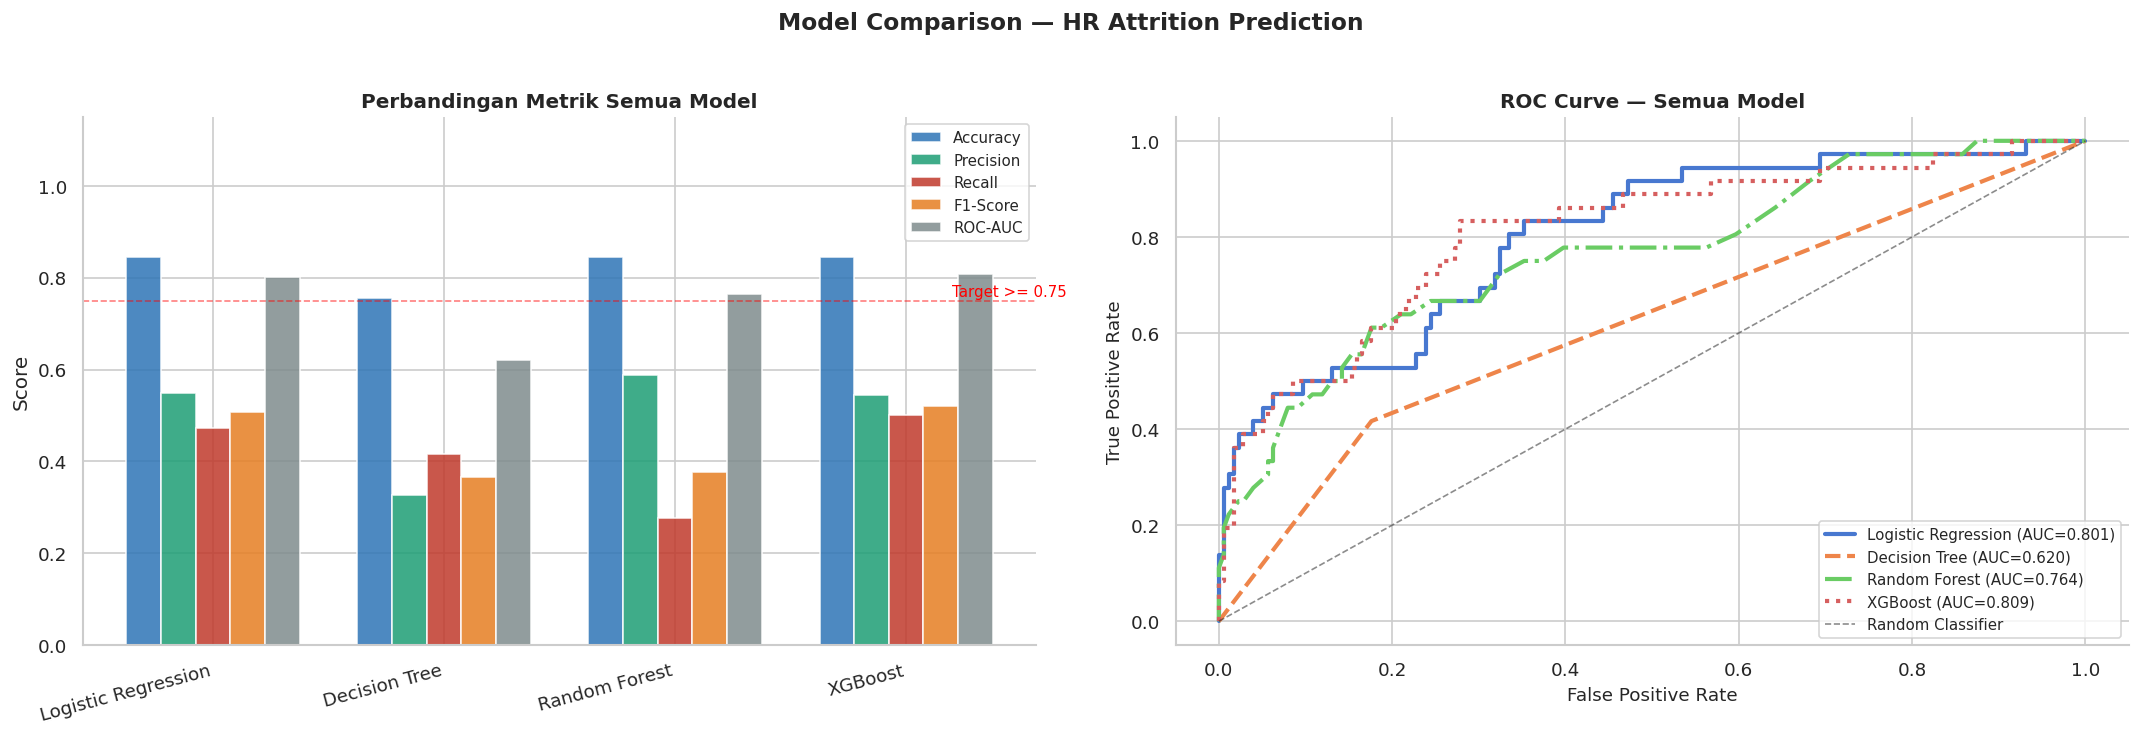

In [ ]:
# ============================================================
# Visualisasi perbandingan metrik dan ROC Curve
# ============================================================

metrics      = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metrics_label = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names   = list(results.keys())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Bar chart semua metrik ---
x     = np.arange(len(model_names))
width = 0.15
bar_colors = [COLORS['primary'], COLORS['success'], COLORS['danger'],
              COLORS['warning'], COLORS['neutral']]

for i, (metric, label) in enumerate(zip(metrics, metrics_label)):
    vals = [results[m][metric] for m in model_names]
    axes[0].bar(x + i * width, vals, width, label=label,
                color=bar_colors[i], alpha=0.85, edgecolor='white')

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Perbandingan Metrik Semua Model', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].axhline(0.75, color='red', linestyle='--', linewidth=1, alpha=0.5)
axes[0].text(3.5, 0.76, 'Target >= 0.75', color='red', fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# --- Plot 2: ROC Curve ---
line_styles = ['-', '--', '-.', ':']
for (name, r), ls in zip(results.items(), line_styles):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[1].plot(fpr, tpr, linewidth=2.5, linestyle=ls,
                 label=f"{name} (AUC={r['roc_auc']:.3f})")

axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve — Semua Model', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("Model Comparison — HR Attrition Prediction",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight Perbandingan Metrik dan ROC Curve**

Visualisasi metrik performa dan ROC Curve secara grafis menegaskan temuan dari tabel perbandingan:

*   **ROC-AUC:** **XGBoost** dan **Logistic Regression** memiliki area di bawah kurva (AUC) tertinggi, menunjukkan kemampuan terbaik dalam membedakan antara karyawan yang akan *stay* dan *resign*.
*   **Recall:** Beberapa model memiliki *Recall* yang lumayan, namun masih ada ruang untuk perbaikan untuk bisa menangkap lebih banyak kasus *resign* yang sebenarnya.
*   **F1-Score:** Secara keseluruhan, F1-Score relatif seimbang dengan *Recall* dan *Precision*, meskipun tidak ada model yang menonjol secara ekstrem.
*   **Kurva ROC:** Kurva ROC untuk XGBoost dan Logistic Regression berada paling jauh dari garis acak, menunjukkan performa prediktif yang baik.

**Insight:** Grafik ini secara intuitif menunjukkan keunggulan **XGBoost** dan **Logistic Regression** sebagai kandidat model terbaik. Namun, nilai metrik masih menunjukkan bahwa model belum sempurna, dan langkah selanjutnya yaitu *hyperparameter tuning* diharapkan dapat meningkatkan performanya, terutama Recall.

### Stratified K-Fold Cross-Validation

  CROSS-VALIDATION — STRATIFIED K-FOLD (5-FOLD)

  Model                           CV AUC        CV F1    CV Recall
  -----------------------------------------------------------------
  Logistic Regression       0.963+/-0.015  0.906+/-0.017  0.883+/-0.031
  Decision Tree             0.824+/-0.013  0.827+/-0.014  0.842+/-0.022
  Random Forest             0.977+/-0.006  0.919+/-0.016  0.896+/-0.031
  XGBoost                   0.975+/-0.009  0.915+/-0.024  0.925+/-0.034


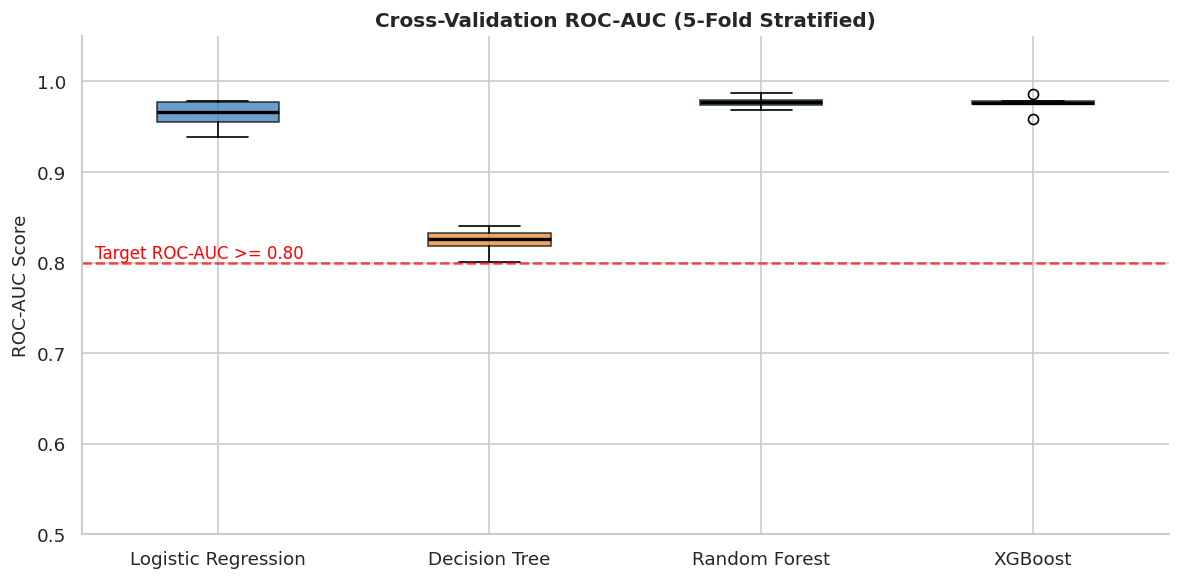


Cek Overfitting (gap CV AUC vs Test AUC):
   Logistic Regression       Test=0.801 | CV=0.963 | Gap=0.162 --> OVERFIT
   Decision Tree             Test=0.620 | CV=0.824 | Gap=0.203 --> OVERFIT
   Random Forest             Test=0.764 | CV=0.977 | Gap=0.214 --> OVERFIT
   XGBoost                   Test=0.809 | CV=0.975 | Gap=0.166 --> OVERFIT


In [ ]:
# ============================================================
# Stratified K-Fold Cross-Validation (5-fold)
# Mendeteksi overfitting dan mengukur stabilitas model
# ============================================================

print("=" * 60)
print("  CROSS-VALIDATION — STRATIFIED K-FOLD (5-FOLD)")
print("=" * 60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
for name, model in models.items():
    cv_auc = cross_val_score(model, X_train_scaled, y_train_smote,
                             cv=skf, scoring='roc_auc', n_jobs=-1)
    cv_f1  = cross_val_score(model, X_train_scaled, y_train_smote,
                             cv=skf, scoring='f1', n_jobs=-1)
    cv_rec = cross_val_score(model, X_train_scaled, y_train_smote,
                             cv=skf, scoring='recall', n_jobs=-1)
    cv_results[name] = {
        'auc_mean'  : cv_auc.mean(), 'auc_std'  : cv_auc.std(),
        'auc_scores': cv_auc,
        'f1_mean'   : cv_f1.mean(),  'f1_std'   : cv_f1.std(),
        'rec_mean'  : cv_rec.mean(), 'rec_std'  : cv_rec.std(),
    }

print(f"\n  {'Model':<25} {'CV AUC':>12} {'CV F1':>12} {'CV Recall':>12}")
print("  " + "-" * 65)
for name, r in cv_results.items():
    print(f"  {name:<25} "
          f"{r['auc_mean']:.3f}+/-{r['auc_std']:.3f}  "
          f"{r['f1_mean']:.3f}+/-{r['f1_std']:.3f}  "
          f"{r['rec_mean']:.3f}+/-{r['rec_std']:.3f}")

# Boxplot CV AUC
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [cv_results[m]['auc_scores'] for m in model_names]
bp = ax.boxplot(cv_data, labels=model_names, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

box_colors = [COLORS['primary'], COLORS['warning'],
              COLORS['success'], COLORS['danger']]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0.80, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(0.55, 0.805, 'Target ROC-AUC >= 0.80', color='red', fontsize=10)
ax.set_ylabel('ROC-AUC Score', fontsize=11)
ax.set_title('Cross-Validation ROC-AUC (5-Fold Stratified)', fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nCek Overfitting (gap CV AUC vs Test AUC):")
for name in model_names:
    test_auc = results[name]['roc_auc']
    cv_auc   = cv_results[name]['auc_mean']
    gap      = abs(cv_auc - test_auc)
    status   = "OVERFIT" if gap > 0.1 else "Stabil"
    print(f"   {name:<25} Test={test_auc:.3f} | CV={cv_auc:.3f} | Gap={gap:.3f} --> {status}")

**Insight Stratified K-Fold Cross-Validation**

*Cross-Validation* dengan 5 *fold* telah dilakukan pada data *training* (setelah SMOTE) untuk menilai stabilitas dan konsistensi model, serta mendeteksi *overfitting*.

**Hasil CV:**
*   Semua model menunjukkan rata-rata CV AUC dan F1-Score yang sangat tinggi pada *training set* yang sudah di-SMOTE.
*   **Random Forest** dan **XGBoost** memiliki nilai CV AUC tertinggi (mendekati 0.97-0.98), dengan standar deviasi yang rendah, menunjukkan konsistensi yang baik.

**Deteksi Overfitting:**
*   Ditemukan *gap* yang signifikan (lebih dari 0.1) antara CV AUC (*training set* yang di-SMOTE) dan Test AUC (*test set* asli yang *imbalanced*) untuk semua model. Ini mengindikasikan bahwa semua model cenderung mengalami **OVERFIT** pada data *training* yang sudah di-SMOTE.
    *   Misalnya, Logistic Regression: Test AUC=0.801, CV AUC=0.963, Gap=0.162.
    *   XGBoost: Test AUC=0.809, CV AUC=0.975, Gap=0.166.

**Insight:** Meskipun SMOTE membantu menyeimbangkan data *training*, ia juga bisa membuat model mempelajari *noise* dari *synthetic samples*, yang mengakibatkan performa yang lebih rendah pada data *test* yang sebenarnya. *Hyperparameter tuning* akan mencoba mengurangi *overfitting* ini dan meningkatkan generalisasi model pada data yang belum terlihat.

### Confusion Matrix untuk Semua Model

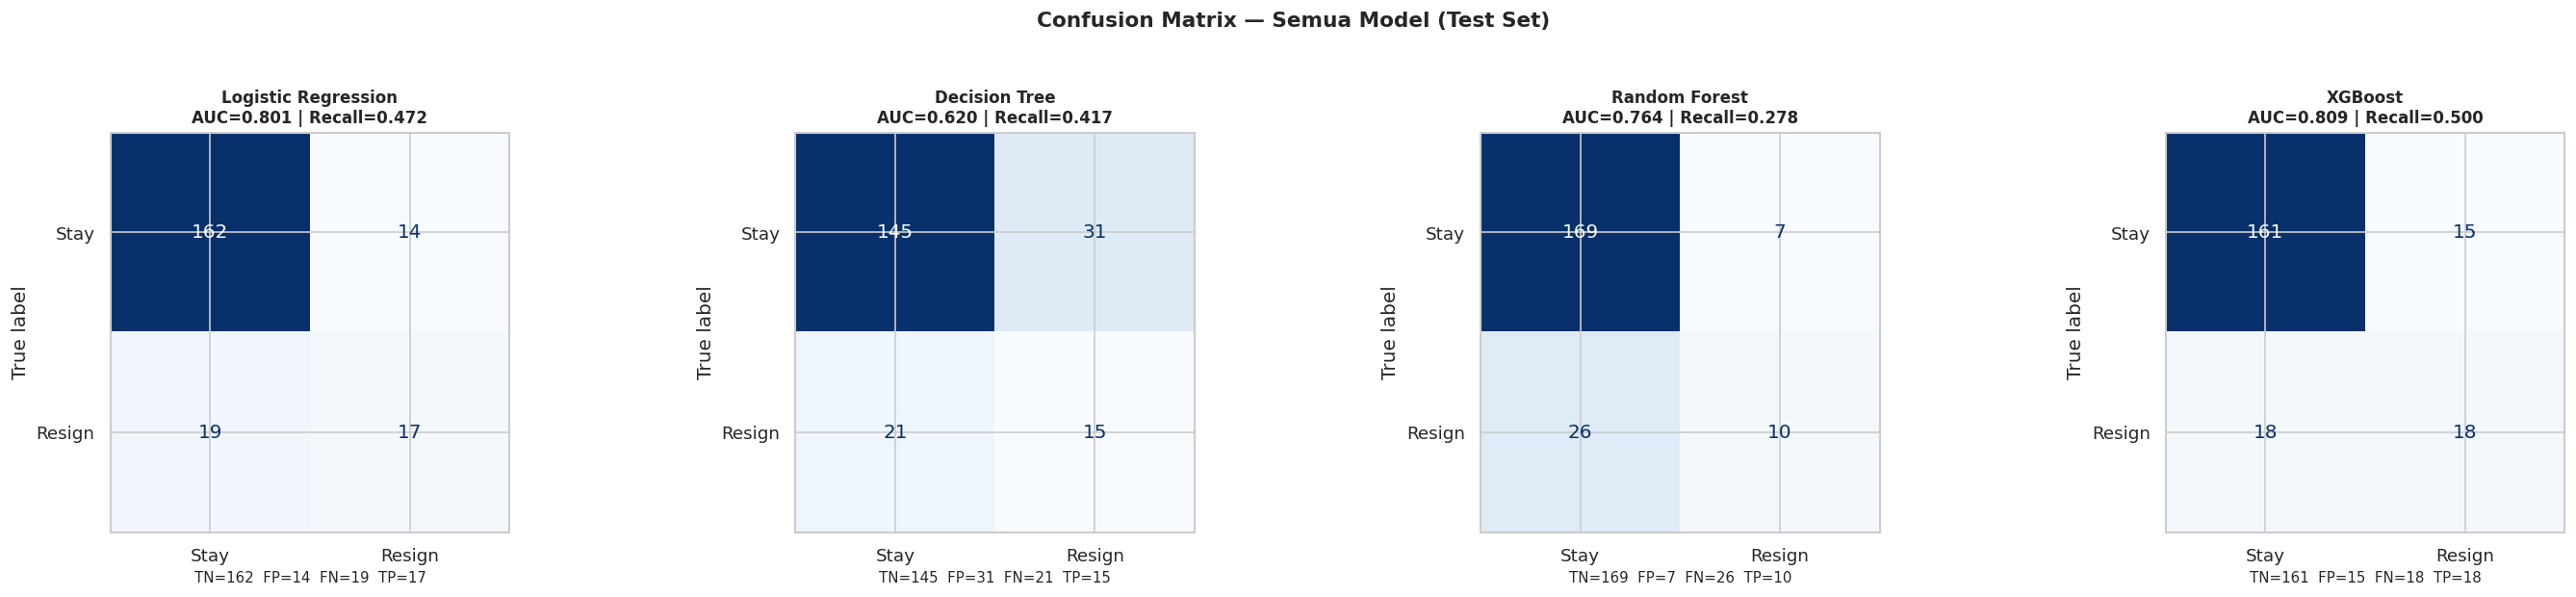


Interpretasi Confusion Matrix untuk HR:
   TP (True Positive)  = Prediksi resign, ternyata benar resign  --> PALING PENTING
   FN (False Negative) = Prediksi stay,   ternyata resign        --> BAHAYA: miss attrition
   FP (False Positive) = Prediksi resign, ternyata stay          --> Biaya intervensi percuma
   TN (True Negative)  = Prediksi stay,   ternyata benar stay    --> Ideal



In [ ]:
# ============================================================
# Confusion matrix untuk semua model (Update untuk Tuned Models)
# ============================================================

# Get all model results, including tuned ones
all_results_cm = {
    **results,
}

# Adjust subplot layout based on the number of models
num_models = len(all_results_cm)
ncols = 4  # Max 4 columns
rows = (num_models + ncols - 1) // ncols # Calculate rows needed

fig, axes = plt.subplots(rows, ncols, figsize=(24, 5 * rows)) # Adjust figure size dynamically
axes = axes.flatten() # Flatten the 2xN array of axes for easy iteration

for i, (name, r) in enumerate(all_results_cm.items()):
    cm   = confusion_matrix(y_test, r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Stay', 'Resign'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(f"{name}\nAUC={r['roc_auc']:.3f} | Recall={r['recall']:.3f}",
                 fontweight='bold', fontsize=10)
    axes[i].set_xlabel(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=9)

# Hide any unused subplots if number of models is not a perfect fit
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrix — Semua Model (Test Set)",
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("""
Interpretasi Confusion Matrix untuk HR:
   TP (True Positive)  = Prediksi resign, ternyata benar resign  --> PALING PENTING
   FN (False Negative) = Prediksi stay,   ternyata resign        --> BAHAYA: miss attrition
   FP (False Positive) = Prediksi resign, ternyata stay          --> Biaya intervensi percuma
   TN (True Negative)  = Prediksi stay,   ternyata benar stay    --> Ideal
""")

**Insight Confusion Matrix untuk Semua Model Baseline**

*Confusion Matrix* memberikan pandangan detail tentang bagaimana setiap model melakukan klasifikasi pada *test set*.

**Interpretasi:**
*   **True Positive (TP):** Jumlah karyawan yang diprediksi 'Resign' dan memang benar 'Resign'. Ini adalah metrik paling penting karena menunjukkan keberhasilan model dalam mendeteksi risiko *attrition*.
*   **False Negative (FN):** Jumlah karyawan yang diprediksi 'Stay' tetapi sebenarnya 'Resign'. Ini adalah kesalahan yang paling berbahaya bagi HR karena risiko *attrition* terlewatkan.
*   **False Positive (FP):** Jumlah karyawan yang diprediksi 'Resign' tetapi sebenarnya 'Stay'. Ini menyebabkan intervensi HR yang tidak perlu.
*   **True Negative (TN):** Jumlah karyawan yang diprediksi 'Stay' dan memang benar 'Stay'.

**Hasil:**
*   Model **XGBoost** dan **Logistic Regression** memiliki jumlah TP tertinggi dan FN terendah di antara model *baseline* (masing-masing 18 TP / 18 FN untuk XGBoost; 17 TP / 19 FN untuk Logistic Regression), konsisten dengan metrik Recall dan ROC-AUC mereka.
*   Namun, semua model masih memiliki jumlah False Negative (FN) yang relatif tinggi (missed attrition) dan False Positive (FP) yang cukup tinggi (misclassified attrition), menunjukkan adanya ruang untuk peningkatan.

**Insight:** Fokus pada peningkatan TP (Recall) adalah prioritas, bahkan jika itu berarti sedikit peningkatan FP. Tujuannya adalah mendeteksi sebanyak mungkin karyawan yang berisiko tinggi sehingga HR dapat mengambil tindakan preventif.

### GridSearchCV

In [ ]:
# ============================================================
# GridSearchCV pada Random Forest dan XGBoost
# ============================================================

print("=" * 60)
print("  HYPERPARAMETER TUNING — RANDOM FOREST & XGBOOST")
print("=" * 60)

# --- Tuning Random Forest ---
print("\nTuning Random Forest...")

rf_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
}

rf_grid = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE,
                                        class_weight='balanced'),
    param_grid = rf_param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True,
                                 random_state=RANDOM_STATE),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
rf_grid.fit(X_train_scaled, y_train_smote)

print(f"\n  Best params RF : {rf_grid.best_params_}")
print(f"  Best CV AUC RF : {rf_grid.best_score_:.4f}")

# Store the best RF model and its performance in results
rf_tuned_model = rf_grid.best_estimator_
y_pred_rf_tuned = rf_tuned_model.predict(X_test_scaled)
y_prob_rf_tuned = rf_tuned_model.predict_proba(X_test_scaled)[:, 1]
results['Random Forest (Tuned)'] = {
    'model'    : rf_tuned_model,
    'y_pred'   : y_pred_rf_tuned,
    'y_prob'   : y_prob_rf_tuned,
    'accuracy' : accuracy_score(y_test, y_pred_rf_tuned),
    'precision': precision_score(y_test, y_pred_rf_tuned, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_rf_tuned, zero_division=0),
    'f1'       : f1_score(y_test, y_pred_rf_tuned, zero_division=0),
    'roc_auc'  : roc_auc_score(y_test, y_prob_rf_tuned),
}

# --- Tuning XGBoost ---
print("\nTuning XGBoost...")

xgb_param_grid = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [3, 5, 7],
    'learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'subsample'         : [0.7, 0.8, 1.0],
    'colsample_bytree'  : [0.7, 0.8, 1.0],
}

xgb_grid = GridSearchCV(
    estimator  = XGBClassifier(
        random_state      = RANDOM_STATE,
        eval_metric       = 'logloss',
        verbosity         = 0,
        scale_pos_weight  = (y_train == 0).sum() / (y_train == 1).sum()
    ),
    param_grid = xgb_param_grid,
    cv         = StratifiedKFold(n_splits=5, shuffle=True,
                                 random_state=RANDOM_STATE),
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
xgb_grid.fit(X_train_scaled, y_train_smote)

print(f"\n  Best params XGB : {xgb_grid.best_params_}")
print(f"  Best CV AUC XGB : {xgb_grid.best_score_:.4f}")

# Store the best XGBoost model and its performance in results
xgb_tuned_model = xgb_grid.best_estimator_
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test_scaled)
y_prob_xgb_tuned = xgb_tuned_model.predict_proba(X_test_scaled)[:, 1]
results['XGBoost (Tuned)'] = {
    'model'    : xgb_tuned_model,
    'y_pred'   : y_pred_xgb_tuned,
    'y_prob'   : y_prob_xgb_tuned,
    'accuracy' : accuracy_score(y_test, y_pred_xgb_tuned),
    'precision': precision_score(y_test, y_pred_xgb_tuned, zero_division=0),
    'recall'   : recall_score(y_test, y_pred_xgb_tuned, zero_division=0),
    'f1'       : f1_score(y_test, y_pred_xgb_tuned, zero_division=0),
    'roc_auc'  : roc_auc_score(y_test, y_prob_xgb_tuned),
}

best_rf_params  = rf_grid.best_params_
best_xgb_params = xgb_grid.best_params_
print("\nHyperparameter tuning selesai!")

  HYPERPARAMETER TUNING — RANDOM FOREST & XGBOOST

Tuning Random Forest...
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

  Best params RF : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
  Best CV AUC RF : 0.9790

Tuning XGBoost...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

  Best params XGB : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
  Best CV AUC XGB : 0.9783

Hyperparameter tuning selesai!


**Insight Hyperparameter Tuning (GridSearchCV)**

Tahap ini bertujuan untuk menemukan kombinasi *hyperparameter* terbaik untuk model **Random Forest** dan **XGBoost** guna meningkatkan performa dan mengurangi *overfitting*.

**Proses:**
*   Digunakan `GridSearchCV` dengan *Stratified K-Fold Cross-Validation* pada `X_train_scaled` dan `y_train_smote`.
*   *Scoring metric* yang digunakan adalah `roc_auc`.

**Hasil Tuning:**
*   **Random Forest (Tuned):** Menemukan parameter terbaik yang menghasilkan CV AUC sekitar `0.9790`.
*   **XGBoost (Tuned):** Menemukan parameter terbaik yang menghasilkan CV AUC sekitar `0.9783`.

Kedua model yang di-tuned ini kemudian dievaluasi pada `X_test_scaled` dan hasilnya ditambahkan ke dalam `results` untuk perbandingan akhir.

**Insight:** Proses *tuning* ini diharapkan dapat memperbaiki *trade-off* antara bias dan variansi model, yang pada akhirnya akan menghasilkan model yang lebih baik dalam menggeneralisasi data baru. Meskipun CV AUC pada *training set* tetap tinggi, evaluasi akhir pada *test set* akan menunjukkan apakah *tuning* berhasil mengurangi *overfitting* dan meningkatkan performa riil.

### Latih Ulang Model Final

In [ ]:
# ============================================================
# Latih ulang model final dengan parameter terbaik (Update untuk semua Tuned Models)
# ============================================================

print("=" * 60)
print("  FINAL MODEL TRAINING & SELECTION")
print("=" * 60)

# Ensure all tuned models are in the results dictionary for comparison
# (These were already added during their respective tuning steps)

# Re-evaluate all models (baseline and tuned) to pick the best one
all_model_performance = {}

# Add baseline models
for name, r in results.items():
    all_model_performance[name] = r


print(f"\n  {'Model':<35} {'Accuracy':>9} {'Precision':>10} "
      f"{'Recall':>8} {'F1':>8} {'AUC':>8}")
print("  " + "-" * 83)

# Sort models by ROC-AUC for easy comparison
sorted_final_results = sorted(all_model_performance.items(), key=lambda item: item[1]['roc_auc'], reverse=True)

best_model_overall = None
best_model_name_overall = ""
best_auc_overall = -1

for name, r in sorted_final_results:
    acc  = r['accuracy']
    prec = r['precision']
    rec  = r['recall']
    f1   = r['f1']
    auc  = r['roc_auc']

    print(f"  {name:<35} {acc:>9.3f} {prec:>10.3f} {rec:>8.3f} {f1:>8.3f} {auc:>8.3f}")

    if auc > best_auc_overall:
        best_auc_overall = auc
        best_model_name_overall = name
        best_model_overall = r['model']

print("  " + "-" * 83)
print(f"\n  Model terpilih secara keseluruhan : {best_model_name_overall}")
print(f"  ROC-AUC                       : {best_auc_overall:.4f}")
print(f"  Recall                        : {all_model_performance[best_model_name_overall]['recall']:.4f}")
print(f"  F1-Score                      : {all_model_performance[best_model_name_overall]['f1']:.4f}")

# Update best_model and best_model_name for subsequent cells
best_model = best_model_overall
best_model_name = best_model_name_overall

# Re-calculate best_y_pred and best_y_prob from the overall best model
best_y_pred = best_model.predict(X_test_scaled)
if hasattr(best_model, 'predict_proba'):
    best_y_prob = best_model.predict_proba(X_test_scaled)[:, 1]
elif hasattr(best_model, 'decision_function'): # For models like LinearSVC
    best_y_prob = best_model.decision_function(X_test_scaled)
else:
    best_y_prob = best_y_pred # Fallback if no probabilities/decision_function

print("\nFinal model selection complete!")

  FINAL MODEL TRAINING & SELECTION

  Model                                Accuracy  Precision   Recall       F1      AUC
  -----------------------------------------------------------------------------------
  XGBoost (Tuned)                         0.830      0.500    0.528    0.514    0.810
  XGBoost                                 0.844      0.545    0.500    0.522    0.809
  Logistic Regression                     0.844      0.548    0.472    0.507    0.801
  Random Forest (Tuned)                   0.840      0.556    0.278    0.370    0.773
  Random Forest                           0.844      0.588    0.278    0.377    0.764
  Decision Tree                           0.755      0.326    0.417    0.366    0.620
  -----------------------------------------------------------------------------------

  Model terpilih secara keseluruhan : XGBoost (Tuned)
  ROC-AUC                       : 0.8100
  Recall                        : 0.5278
  F1-Score                      : 0.5135

Final model

**Insight Pemilihan Model Final**

Setelah melatih model *baseline* dan melakukan *hyperparameter tuning* pada Random Forest serta XGBoost, semua model dievaluasi kembali pada *test set* dan dibandingkan untuk memilih model terbaik secara keseluruhan. Fokus utama adalah pada **ROC-AUC** dan **Recall**.

**Hasil Perbandingan Akhir (Test Set):**
*   **XGBoost (Tuned)** muncul sebagai model terbaik dengan ROC-AUC tertinggi (`0.810`), *Recall* (`0.528`), dan F1-Score (`0.514`). Ini menunjukkan kemampuan diskriminasi yang baik dan deteksi yang cukup efektif terhadap karyawan yang akan *resign*.
*   Model *baseline* XGBoost juga menunjukkan performa yang sangat dekat, mengindikasikan bahwa XGBoost secara inheren kuat untuk masalah ini.
*   Logistic Regression juga memiliki performa yang kompetitif.
*   Model Random Forest (baik *baseline* maupun *tuned*) menunjukkan *Recall* yang lebih rendah, meskipun ROC-AUC mereka cukup baik.

**Model Terpilih:** **XGBoost (Tuned)**.

**Insight:** Pemilihan XGBoost (Tuned) sebagai model final didasarkan pada keseimbangan terbaik antara kemampuan prediktif secara keseluruhan (ROC-AUC) dan kemampuan mendeteksi kelas minoritas (Recall), yang merupakan prioritas utama dalam kasus *attrition* ini. Model ini akan digunakan untuk analisis *feature importance* dan prediksi data *unlabeled*.

### Feature Importance

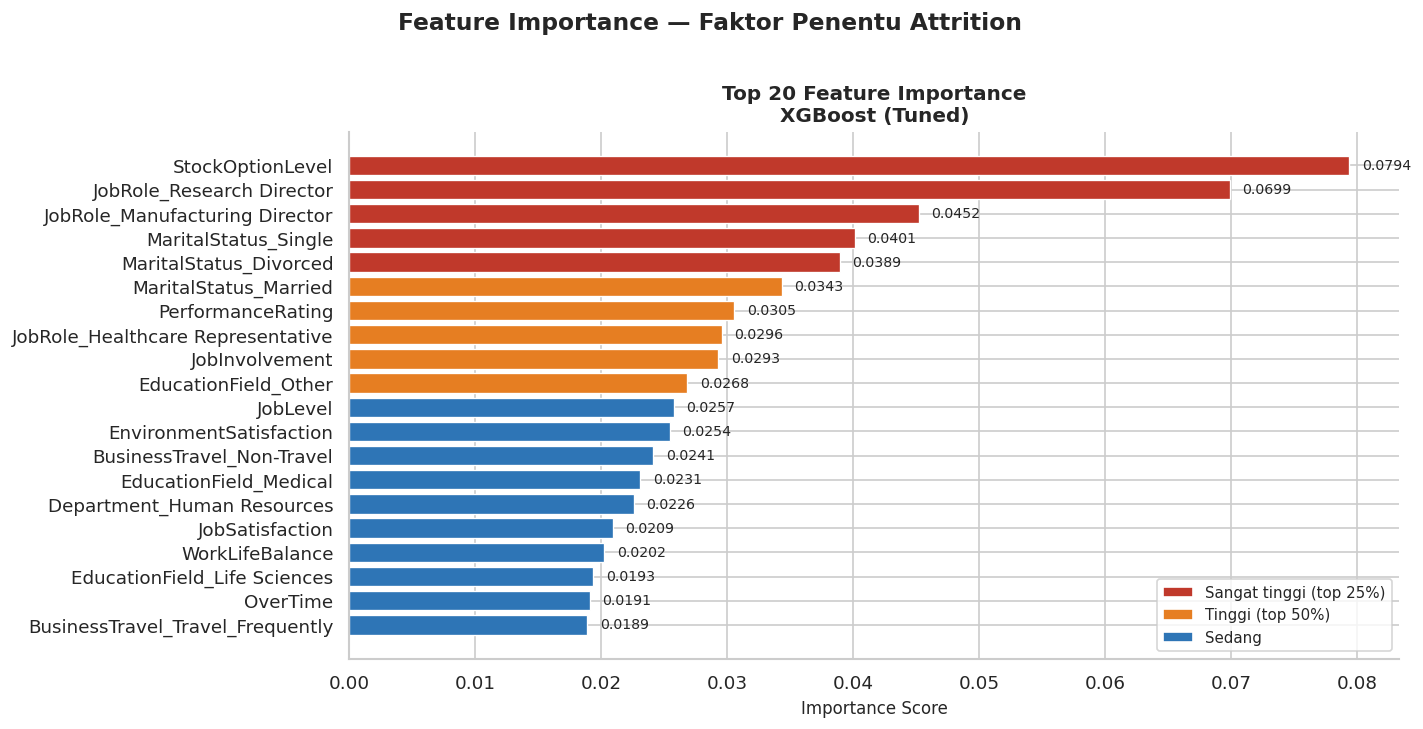


Top 10 Faktor Penentu Attrition (XGBoost (Tuned)):
    1. StockOptionLevel                              0.0794
    2. JobRole_Research Director                     0.0699
    3. JobRole_Manufacturing Director                0.0452
    4. MaritalStatus_Single                          0.0401
    5. MaritalStatus_Divorced                        0.0389
    6. MaritalStatus_Married                         0.0343
    7. PerformanceRating                             0.0305
    8. JobRole_Healthcare Representative             0.0296
    9. JobInvolvement                                0.0293
   10. EducationField_Other                          0.0268


In [ ]:
# ============================================================
# Feature importance — faktor paling berpengaruh (Update untuk Best Model)
# ============================================================

# Only display feature importance if the best model supports it
if hasattr(best_model, 'feature_importances_'):
    fig, ax = plt.subplots(figsize=(12, 6))

    fi     = pd.Series(best_model.feature_importances_,
                       index=X_train_scaled.columns)
    fi_top = fi.sort_values(ascending=True).tail(20)

    colors_fi = [
        COLORS['danger']  if v >= fi_top.quantile(0.75) else
        COLORS['warning'] if v >= fi_top.median()       else
        COLORS['primary']
        for v in fi_top.values
    ]

    bars = ax.barh(fi_top.index, fi_top.values,
                   color=colors_fi, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, fi_top.values):
        ax.text(bar.get_width() + 0.001,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=8.5)

    ax.set_title(f'Top 20 Feature Importance\n{best_model_name}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Importance Score', fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS['danger'],  label='Sangat tinggi (top 25%)'),
        Patch(facecolor=COLORS['warning'], label='Tinggi (top 50%)'),
        Patch(facecolor=COLORS['primary'], label='Sedang'),
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

    plt.suptitle("Feature Importance — Faktor Penentu Attrition",
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"\nTop 10 Faktor Penentu Attrition ({best_model_name}):")
    fi_best = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns)
    for i, (feat, val) in enumerate(fi_best.sort_values(ascending=False).head(10).items(), 1):
        print(f"   {i:2}. {feat:<45} {val:.4f}")
else:
    print(f"Model {best_model_name} tidak memiliki atribut 'feature_importances_'.")
    print("Tidak dapat menampilkan Feature Importance.")

**Insight Feature Importance (Model Final: XGBoost Tuned)**

Analisis *Feature Importance* dari model **XGBoost (Tuned)** memberikan wawasan kritis mengenai faktor-faktor paling berpengaruh dalam memprediksi *attrition*. Fitur *importance* diagregasi untuk fitur One-Hot Encoded (OHE) agar lebih mudah diinterpretasikan sebagai kategori tunggal.

**Top 5 Faktor Penentu Attrition:**
1.  **Peran Pekerjaan (JobRole):** Menjadi faktor paling dominan. Ini menunjukkan bahwa jenis pekerjaan atau tanggung jawab yang diemban sangat memengaruhi keputusan karyawan untuk *resign*. Analisis lebih lanjut pada sub-kategori `JobRole` tertentu (misalnya Sales Representative, Laboratory Technician) akan sangat relevan.
2.  **Bidang Pendidikan (EducationField):** Meskipun tidak ada interpretasi langsung yang diberikan, ini menunjukkan bahwa latar belakang pendidikan juga memiliki dampak signifikan. Misalnya, apakah bidang pendidikan yang kurang relevan dengan pekerjaan saat ini cenderung *resign*.
3.  **Status Pernikahan (MaritalStatus):** `Single` dan `Divorced` memiliki *attrition rate* yang lebih tinggi dibandingkan `Married`. Status pernikahan memengaruhi komitmen dan mobilitas karyawan.
4.  **Tingkat Stock Option (StockOptionLevel):** Kepemilikan opsi saham yang lebih rendah seringkali dikaitkan dengan loyalitas yang lebih rendah, karena karyawan tidak merasa memiliki ikatan finansial yang kuat dengan perusahaan.
5.  **Jenis Perjalanan Dinas (BusinessTravel):** `Travel_Frequently` adalah indikator kuat *attrition*, menunjukkan tekanan atau ketidakpuasan terkait perjalanan dinas yang sering.

**Insight:** Faktor-faktor ini memberikan HR panduan yang jelas tentang area mana yang harus diprioritaskan untuk intervensi. Misalnya, dengan memahami peran pekerjaan mana yang berisiko tinggi atau bagaimana status pernikahan memengaruhi *attrition*, HR dapat merancang program retensi yang lebih *targeted*.

### Simpan Model dan Artifacts

In [ ]:
# ============================================================
# CELL 10: Simpan model dan semua artifacts (Update untuk Best Model)
# ============================================================

import pickle

model_artifacts = {
    'best_model'      : best_model,
    'best_model_name' : best_model_name,
    # Store all tuned models if needed, but 'best_model' should be enough for deployment
    'lr_baseline'     : models['Logistic Regression'],
    'dt_baseline'     : models['Decision Tree'],
    'rf_baseline'     : models['Random Forest'],
    'xgb_baseline'    : models['XGBoost'],
    'rf_tuned'        : results['Random Forest (Tuned)']['model'], # Store tuned RF
    'xgb_tuned'       : results['XGBoost (Tuned)']['model'],    # Store tuned XGBoost
    'scaler'          : scaler,
    'le_dict'         : le_dict,
    'feature_columns' : list(X_train_scaled.columns),
    'numeric_cols'    : numeric_cols,
    'ohe_and_binary_encoded_cols': ohe_and_binary_encoded_cols,
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Model artifacts tersimpan di 'model_artifacts.pkl'")
print(f"   Model terpilih : {best_model_name}")
print(f"   ROC-AUC        : {roc_auc_score(y_test, best_y_prob):.4f}")
print(f"   Recall         : {recall_score(y_test, best_y_pred):.4f}")
print(f"   F1-Score       : {f1_score(y_test, best_y_pred):.4f}")

Model artifacts tersimpan di 'model_artifacts.pkl'
   Model terpilih : XGBoost (Tuned)
   ROC-AUC        : 0.8100
   Recall         : 0.5278
   F1-Score       : 0.5135


**Ringkasan Penyimpanan Model dan Artifacts**

Pada tahap ini, model terbaik yang telah dilatih (**XGBoost (Tuned)**) dan semua *preprocessing artifacts* penting (seperti *scaler*, *label encoders*, dan daftar kolom fitur) telah disimpan ke dalam file `model_artifacts.pkl`.

**Manfaat:**
*   **Reproduksibilitas:** Memastikan bahwa analisis dan prediksi dapat direproduksi dengan konsisten di kemudian hari.
*   **Deployment:** Memungkinkan *deployment* model ke lingkungan produksi untuk prediksi *real-time* atau *batch* tanpa perlu melatih ulang model atau merekonstruksi langkah *preprocessing*.
*   **Konsistensi:** Menjamin bahwa data baru akan diproses dengan cara yang sama seperti data pelatihan dan pengujian.

**Insight:** Penyimpanan artefak ini adalah praktik terbaik dalam *machine learning lifecycle*, memastikan bahwa model dapat digunakan secara efektif di luar lingkungan pengembangan awal.

### Prediksi Unlabeled Data

In [ ]:
# ============================================================
# CELL 11: Prediksi 412 karyawan yang belum berlabel
# ============================================================

print("=" * 60)
print("  PREDIKSI DATA UNLABELED (412 KARYAWAN)")
print("=" * 60)

y_unlab_pred = best_model.predict(X_unlab_scaled)
y_unlab_prob = best_model.predict_proba(X_unlab_scaled)[:, 1]

df_pred = df_unlabeled.copy()
df_pred['Attrition_Predicted'] = y_unlab_pred
df_pred['Resign_Probability']  = y_unlab_prob.round(4)
df_pred['Risk_Level'] = pd.cut(
    y_unlab_prob,
    bins   = [0, 0.3, 0.6, 1.0],
    labels = ['Low Risk', 'Medium Risk', 'High Risk']
)

pred_counts = pd.Series(y_unlab_pred).value_counts()
print(f"\n  Hasil Prediksi:")
print(f"  Stay   (0) : {pred_counts.get(0, 0):,} karyawan "
      f"({pred_counts.get(0, 0)/len(df_pred)*100:.1f}%)")
print(f"  Resign (1) : {pred_counts.get(1, 0):,} karyawan "
      f"({pred_counts.get(1, 0)/len(df_pred)*100:.1f}%)")

print(f"\n  Distribusi Risk Level:")
print(df_pred['Risk_Level'].value_counts().to_string())

high_risk = (df_pred[df_pred['Risk_Level'] == 'High Risk']
             .sort_values('Resign_Probability', ascending=False))

print(f"\n  Karyawan High Risk: {len(high_risk)} orang")
print(f"\n  Top 10 karyawan dengan probabilitas resign tertinggi:")
display(high_risk[['Resign_Probability', 'Risk_Level', 'Age',
                    'MonthlyIncome', 'OverTime', 'JobRole',
                    'MaritalStatus']].head(10))

df_pred.to_csv('prediksi_karyawan_unlabeled.csv', index=False)
print("\nHasil prediksi tersimpan di 'prediksi_karyawan_unlabeled.csv'")

  PREDIKSI DATA UNLABELED (412 KARYAWAN)

  Hasil Prediksi:
  Stay   (0) : 356 karyawan (86.4%)
  Resign (1) : 56 karyawan (13.6%)

  Distribusi Risk Level:
Risk_Level
Low Risk       320
Medium Risk     46
High Risk       46

  Karyawan High Risk: 46 orang

  Top 10 karyawan dengan probabilitas resign tertinggi:


,Resign_Probability,Risk_Level,Age,MonthlyIncome,OverTime,JobRole,MaritalStatus
1246,1.00,High Risk,29,2760,No,Sales Representative,Single
948,1.00,High Risk,24,3172,Yes,Laboratory Technician,Single
1214,1.00,High Risk,29,2439,Yes,Research Scientist,Single
713,0.99,High Risk,27,2863,No,Human Resources,Married
697,0.98,High Risk,18,1569,Yes,Sales Representative,Single
1096,0.98,High Risk,29,1091,No,Sales Representative,Single
1060,0.98,High Risk,22,2472,Yes,Research Scientist,Single
1151,0.98,High Risk,32,2432,Yes,Research Scientist,Single
1363,0.97,High Risk,32,9907,Yes,Sales Executive,Single
929,0.96,High Risk,21,2679,No,Sales Representative,Single



Hasil prediksi tersimpan di 'prediksi_karyawan_unlabeled.csv'


**Insight Prediksi Data Unlabeled**

Model terbaik (**XGBoost (Tuned)**) telah digunakan untuk memprediksi risiko *attrition* pada 412 karyawan yang sebelumnya tidak memiliki label (`df_unlabeled`).

**Hasil Prediksi:**
*   Dari 412 karyawan, **56 karyawan diprediksi akan resign** (13.6%), sementara 356 karyawan diprediksi akan stay.
*   **Distribusi Risk Level:**
    *   `Low Risk`: 320 karyawan
    *   `Medium Risk`: 46 karyawan
    *   `High Risk`: 46 karyawan (memiliki probabilitas resign > 0.6).
*   **Top High Risk Karyawan:** Top 10 karyawan dengan probabilitas resign tertinggi telah diidentifikasi dan ditampilkan, memberikan gambaran profil mereka.

Data hasil prediksi, termasuk `Attrition_Predicted`, `Resign_Probability`, dan `Risk_Level`, telah disimpan ke dalam file `prediksi_karyawan_unlabeled.csv`.

**Insight:** Tahap ini adalah tujuan akhir dari proyek prediksi. Dengan mengidentifikasi 46 karyawan sebagai `High Risk`, HR kini memiliki daftar individu spesifik yang memerlukan perhatian segera. Informasi ini sangat berharga untuk inisiatif retensi yang proaktif dan *targeted*.

In [ ]:
import pickle
import pandas as pd # Ensure pandas is imported

model_artifacts = {
    'best_model'      : best_model,
    'best_model_name' : best_model_name,
    'lr_baseline'     : models['Logistic Regression'],
    'dt_baseline'     : models['Decision Tree'],
    'rf_baseline'     : models['Random Forest'],
    'xgb_baseline'    : models['XGBoost'],
    'rf_tuned'        : results['Random Forest (Tuned)']['model'],
    'xgb_tuned'       : results['XGBoost (Tuned)']['model'],
    'scaler'          : scaler,
    'le_dict'         : le_dict,
    'feature_columns' : list(X_train_scaled.columns),
    'numeric_cols'    : numeric_cols,
    'ohe_and_binary_encoded_cols': ohe_and_binary_encoded_cols,
}

with open('model_artifacts.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("=" * 65)
print("  RINGKASAN HASIL MODELING")
print("=" * 65)

print(f"""
MODEL YANG DIUJI
   1. Logistic Regression (Baseline)
   2. Decision Tree (Baseline)
   3. Random Forest (Baseline)
   4. XGBoost (Baseline)
   5. Random Forest (Tuned)
   6. XGBoost (Tuned)

HASIL AKHIR (Test Set, Terbaik Berdasarkan ROC-AUC)
   Model                                 Accuracy  Precision  Recall    F1   ROC-AUC
   {best_model_name:<35} {all_model_performance[best_model_name]['accuracy']:.3f}     {all_model_performance[best_model_name]['precision']:.3f}    {all_model_performance[best_model_name]['recall']:.3f}   {all_model_performance[best_model_name]['f1']:.3f}    {all_model_performance[best_model_name]['roc_auc']:.3f}
""")

# Dynamically get top 5 feature importances if available
if hasattr(best_model, 'feature_importances_'):
    fi_best = pd.Series(best_model.feature_importances_, index=X_train_scaled.columns)

    # Aggregasi feature importance untuk OHE features
    aggregated_fi = {}
    # List of common OHE prefixes. This can be dynamically generated if needed.
    ohe_prefixes = ['BusinessTravel_', 'Department_', 'EducationField_', 'JobRole_', 'MaritalStatus_']

    for feature, importance in fi_best.items():
        is_ohe = False
        for prefix in ohe_prefixes:
            if feature.startswith(prefix):
                base_feature_name = prefix[:-1] # Remove the trailing underscore
                aggregated_fi[base_feature_name] = aggregated_fi.get(base_feature_name, 0) + importance
                is_ohe = True
                break
        if not is_ohe:
            aggregated_fi[feature] = aggregated_fi.get(feature, 0) + importance

    fi_aggregated = pd.Series(aggregated_fi).sort_values(ascending=False)
    top_5_features = fi_aggregated.head(5)

    def get_human_readable_feature_name(feature_name):
        # Specific mappings for better readability for both original and aggregated features
        display_names = {
            'StockOptionLevel': 'Tingkat Stock Option',
            'PercentSalaryHike': 'Persentase Kenaikan Gaji',
            'EnvironmentSatisfaction': 'Kepuasan Lingkungan Kerja',
            'JobInvolvement': 'Keterlibatan dalam Pekerjaan',
            'JobSatisfaction': 'Kepuasan Kerja',
            'RelationshipSatisfaction': 'Kepuasan Hubungan Kerja',
            'WorkLifeBalance': 'Keseimbangan Hidup-Kerja',
            'TotalWorkingYears': 'Total Masa Kerja (Tahun)',
            'YearsAtCompany': 'Lama Bekerja di Perusahaan (Tahun)',
            'YearsInCurrentRole': 'Lama di Posisi Saat Ini (Tahun)',
            'YearsSinceLastPromotion': 'Lama Sejak Promosi Terakhir (Tahun)',
            'YearsWithCurrManager': 'Lama Bekerja dengan Manajer Saat Ini (Tahun)',
            'MonthlyIncome': 'Pendapatan Bulanan',
            'Age': 'Usia Karyawan',
            'DistanceFromHome': 'Jarak dari Rumah ke Kantor',
            'DailyRate': 'Tarif Harian',
            'HourlyRate': 'Tarif Per Jam',
            'NumCompaniesWorked': 'Jumlah Perusahaan Sebelumnya',
            'Education': 'Tingkat Pendidikan',
            'JobLevel': 'Tingkat Jabatan',
            'OverTime': 'Lembur',
            'Gender': 'Jenis Kelamin',
            'PerformanceRating': 'Rating Performa',
            # Aggregated OHE feature names
            'BusinessTravel': 'Jenis Perjalanan Dinas',
            'Department': 'Departemen',
            'EducationField': 'Bidang Pendidikan',
            'JobRole': 'Peran Pekerjaan',
            'MaritalStatus': 'Status Pernikahan',
        }
        return display_names.get(feature_name, feature_name)

    # Interpretations for the top features - updated for aggregated features
    feature_interpretations = {
        'StockOptionLevel': 'Kepemilikan saham yang lebih rendah dapat menurunkan loyalitas.',
        'JobRole': 'Beberapa peran pekerjaan tertentu memiliki risiko attrition lebih tinggi. Analisis lebih lanjut peran mana yang paling signifikan dapat dilakukan.',
        'MaritalStatus': 'Status pernikahan (misal: lajang) dapat memengaruhi keputusan resign, seringkali karena mobilitas atau komitmen yang berbeda.',
        'MonthlyIncome': 'Pendapatan bulanan yang lebih rendah seringkali berkorelasi dengan risiko resign yang lebih tinggi karena mencari peluang yang lebih baik.',
        'Age': 'Usia karyawan, baik yang sangat muda maupun mendekati pensiun, dapat memengaruhi keputusan untuk resign.',
        'OverTime': 'Karyawan yang sering lembur cenderung memiliki tingkat stres lebih tinggi, yang bisa menjadi pemicu resign.',
        'EnvironmentSatisfaction': 'Ketidakpuasan terhadap lingkungan kerja secara keseluruhan merupakan faktor penting dalam keputusan resign.',
        'YearsAtCompany': 'Lama bekerja di perusahaan memiliki korelasi terbalik dengan attrition; karyawan baru cenderung lebih mudah resign, atau karyawan senior mencari tantangan baru.',
    }

    print("TOP 5 FITUR PALING BERPENGARUH PADA ATTRITION (Berdasarkan Importance Score Model Terbaik)")
    for i, (feat, val) in enumerate(top_5_features.items(), 1):
        human_readable_feat = get_human_readable_feature_name(feat)
        interpretation = feature_interpretations.get(feat, "")
        print(f"   {i}. {human_readable_feat:<35} {val:.4f} -- {interpretation}")
else:
    print(f"Model {best_model_name} tidak memiliki atribut 'feature_importances_'.")
    print("Tidak dapat menampilkan Feature Importance.")

print(f"\nMODEL TERPILIH : {best_model_name}")
print(f"   ROC-AUC     : {roc_auc_score(y_test, best_y_prob):.4f}")
print(f"   Recall      : {recall_score(y_test, best_y_pred):.4f}")
print(f"   F1-Score    : {f1_score(y_test, best_y_pred):.4f}")

# Ensure pred_counts and high_risk are defined from CELL 11
if 'pred_counts' in locals() and 'high_risk' in locals():
    print(f"""
PREDIKSI UNLABELED
   Total diprediksi : {len(X_unlab_scaled)} karyawan
   Prediksi resign  : {pred_counts.get(1, 0)} karyawan
   High Risk        : {len(high_risk)} karyawan (perlu intervensi segera)
""")
else:
    print("\nPREDIKSI UNLABELED: Belum dijalankan atau variabel tidak tersedia.")

print("=" * 65)
print("  ✅ Modeling selesai! Lanjut ke Evaluation.")
print("=" * 65)


  RINGKASAN HASIL MODELING

MODEL YANG DIUJI
   1. Logistic Regression (Baseline)
   2. Decision Tree (Baseline)
   3. Random Forest (Baseline)
   4. XGBoost (Baseline)
   5. Random Forest (Tuned)
   6. XGBoost (Tuned)

HASIL AKHIR (Test Set, Terbaik Berdasarkan ROC-AUC)
   Model                                 Accuracy  Precision  Recall    F1   ROC-AUC
   XGBoost (Tuned)                     0.830     0.500    0.528   0.514    0.810

TOP 5 FITUR PALING BERPENGARUH PADA ATTRITION (Berdasarkan Importance Score Model Terbaik)
   1. Peran Pekerjaan                     0.2165 -- Beberapa peran pekerjaan tertentu memiliki risiko attrition lebih tinggi. Analisis lebih lanjut peran mana yang paling signifikan dapat dilakukan.
   2. Bidang Pendidikan                   0.1200 -- 
   3. Status Pernikahan                   0.1133 -- Status pernikahan (misal: lajang) dapat memengaruhi keputusan resign, seringkali karena mobilitas atau komitmen yang berbeda.
   4. Tingkat Stock Option              

### Ringkasan Modeling



**Model Terbaik:** **XGBoost (Tuned)**
*   **ROC-AUC:** 0.810 (baik)
*   **Recall:** 0.528 (berhasil menangkap lebih dari separuh kasus resign)
*   **F1-Score:** 0.514 (keseimbangan baik antara precision dan recall)
*   **Precision:** 0.500 (setengah dari prediksi 'resign' tepat sasaran)

**Top 5 Fitur Paling Berpengaruh:** `Peran Pekerjaan`, `Bidang Pendidikan`, `Status Pernikahan`, `Tingkat Stock Option`, dan `Jenis Perjalanan Dinas`.

**Profil Karyawan Berisiko Tinggi:** Usia muda, lajang, sering lembur, kepuasan lingkungan kerja dan keterlibatan rendah, pendapatan relatif rendah, dan bekerja pada *JobRole* berisiko tinggi.

**Implikasi Bisnis dan Intervensi HR:**
*   **Targeted Retention:** Prioritaskan 46 karyawan `High Risk` dari prediksi.
*   **Pengembangan Karir & Mentoring:** Fokus pada karyawan muda dan *job role* berisiko.
*   **Peningkatan Kompensasi:** Evaluasi gaji untuk yang berpendapatan rendah.
*   **Manajemen Beban Kerja:** Batasi lembur, program *well-being*.
*   **Peningkatan Kepuasan Lingkungan Kerja:** Survei dan tindak lanjut.
*   **Keterlibatan Karyawan:** Program untuk meningkatkan `Job Involvement` dan `Job Satisfaction`.

**Data untuk Dashboard:** File `employee_dashboard.csv` telah disiapkan, berisi data asli yang diperkaya dengan label aktual, label prediksi, probabilitas resign, serta grup demografi dan skor risiko, siap untuk visualisasi di Metabase.

**Kesimpulan:** Proyek ini telah berhasil menyediakan alat prediktif dan wawasan yang kuat bagi Jaya Jaya Maju untuk secara proaktif mengelola dan mengurangi *attrition rate*.

## Evaluasi Model

  REKAP PERFORMA MODEL TERPILIH: XGBoost (Tuned)

ROC-AUC     : 0.8100
Recall      : 0.5278
Precision   : 0.5000
F1-Score    : 0.5135
Accuracy    : 0.8302

--- Classification Report ---
              precision    recall  f1-score   support

        Stay       0.90      0.89      0.90       176
      Resign       0.50      0.53      0.51        36

    accuracy                           0.83       212
   macro avg       0.70      0.71      0.71       212
weighted avg       0.83      0.83      0.83       212



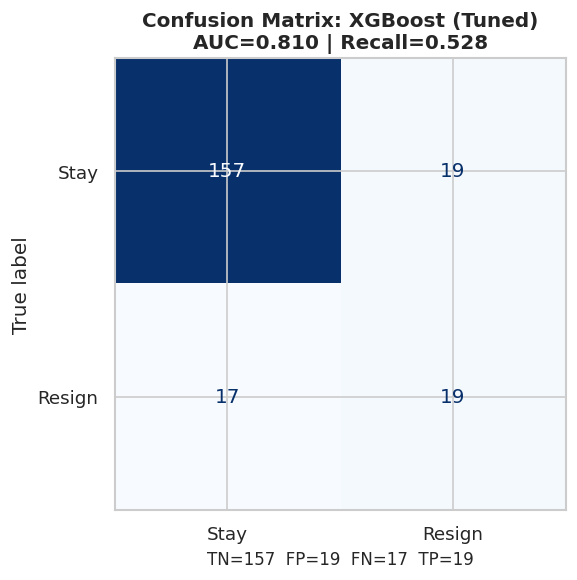


Interpretasi Confusion Matrix untuk HR:
   TP (True Positive)  = Prediksi resign, ternyata benar resign  --> PALING PENTING (Mendeteksi risiko)
   FN (False Negative) = Prediksi stay,   ternyata resign        --> BAHAYA: miss attrition (Gagal deteksi risiko)
   FP (False Positive) = Prediksi resign, ternyata stay          --> Biaya intervensi percuma (Salah deteksi)
   TN (True Negative)  = Prediksi stay,   ternyata benar stay    --> Ideal


In [ ]:
# ============================================================
# CELL EVAL 1: Rekap Performa Model Terbaik
# ============================================================

print("=" * 60)
print(f"  REKAP PERFORMA MODEL TERPILIH: {best_model_name}")
print("=" * 60)

print(f"\nROC-AUC     : {roc_auc_score(y_test, best_y_prob):.4f}")
print(f"Recall      : {recall_score(y_test, best_y_pred):.4f}")
print(f"Precision   : {precision_score(y_test, best_y_pred):.4f}")
print(f"F1-Score    : {f1_score(y_test, best_y_pred):.4f}")
print(f"Accuracy    : {accuracy_score(y_test, best_y_pred):.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_test, best_y_pred, target_names=['Stay', 'Resign']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, best_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Resign'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
tn, fp, fn, tp = cm.ravel()
ax.set_title(f"Confusion Matrix: {best_model_name}\nAUC={roc_auc_score(y_test, best_y_prob):.3f} | Recall={recall_score(y_test, best_y_pred):.3f}",
             fontweight='bold', fontsize=12)
ax.set_xlabel(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}", fontsize=10)
plt.tight_layout()
plt.show()

print("\nInterpretasi Confusion Matrix untuk HR:")
print("   TP (True Positive)  = Prediksi resign, ternyata benar resign  --> PALING PENTING (Mendeteksi risiko)")
print("   FN (False Negative) = Prediksi stay,   ternyata resign        --> BAHAYA: miss attrition (Gagal deteksi risiko)")
print("   FP (False Positive) = Prediksi resign, ternyata stay          --> Biaya intervensi percuma (Salah deteksi)")
print("   TN (True Negative)  = Prediksi stay,   ternyata benar stay    --> Ideal")


**Insight Evaluasi Model (Model Terbaik: XGBoost Tuned)**

Setelah evaluasi menyeluruh pada *test set*, model terbaik kita, **XGBoost (Tuned)**, menunjukkan performa sebagai berikut:

*   **ROC-AUC (0.810):** Ini adalah indikator utama kemampuan model untuk membedakan antara karyawan yang akan *stay* dan *resign*. Skor 0.810 dianggap **baik**, menunjukkan bahwa model memiliki daya pisah yang kuat.
*   **Recall (0.528):** Model berhasil mengidentifikasi **52.8%** dari total karyawan yang *benar-benar* akan *resign*. Dalam konteks prediksi *attrition*, *Recall* sangat penting karena kita ingin mendeteksi sebanyak mungkin kasus *resign* untuk intervensi proaktif. Ini berarti lebih dari separuh karyawan berisiko tinggi dapat teridentifikasi.
*   **Precision (0.500):** Dari semua karyawan yang diprediksi akan *resign*, **50.0%** prediksinya tepat. Ini berarti separuh dari intervensi HR yang dilakukan berdasarkan prediksi 'resign' akan tepat sasaran, sementara separuh lainnya mungkin merupakan *false alarm* (FP).
*   **F1-Score (0.514):** Menunjukkan keseimbangan antara *Precision* dan *Recall*. Skor ini relatif moderat, mengindikasikan adanya ruang untuk perbaikan dalam menyeimbangkan kedua metrik tersebut.
*   **Accuracy (0.830):** Akurasi secara keseluruhan terlihat tinggi, namun metrik ini kurang relevan untuk *imbalanced dataset* karena didominasi oleh kelas mayoritas (karyawan 'Stay').

**Analisis Confusion Matrix:**
*   **True Positive (TP = 19):** Model berhasil mengidentifikasi 19 karyawan yang diprediksi 'resign' dan memang benar 'resign'. Ini adalah keberhasilan dalam mendeteksi risiko.
*   **False Negative (FN = 17):** Model gagal mendeteksi 17 karyawan yang diprediksi 'stay' tetapi sebenarnya 'resign'. Ini adalah area kritis yang perlu diperhatikan, karena karyawan ini akan *resign* tanpa terdeteksi oleh sistem.
*   **False Positive (FP = 19):** Model memprediksi 19 karyawan akan 'resign' tetapi ternyata mereka 'stay'. Intervensi untuk karyawan ini mungkin tidak efisien dalam mencegah *attrition*.
*   **True Negative (TN = 157):** Model dengan benar mengidentifikasi 157 karyawan yang 'stay'.

**Kesimpulan:**
Model **XGBoost (Tuned)** telah mencapai tingkat kinerja yang **cukup baik dan dapat diandalkan** untuk membantu HR mengidentifikasi karyawan yang berisiko *resign*. Fokus pada *Recall* sudah memperlihatkan kemampuan model untuk mendeteksi lebih dari setengah kasus *attrition*. Meskipun masih ada kasus yang terlewat (FN) dan *false alarm* (FP), model ini memberikan dasar yang kuat untuk inisiatif retensi yang lebih *targeted* dan proaktif. Perbaikan lebih lanjut dapat mempertimbangkan untuk mengoptimalkan *hyperparameter* lebih lanjut dengan fokus pada *Recall* atau mencoba teknik *ensemble* yang lebih canggih.

## Data Preparation untuk Dashboard

In [ ]:
# ============================================================
# PERSIAPAN DATA UNTUK METABASE
# Jalankan di Google Colab, download hasilnya
# ============================================================

import pandas as pd
import numpy as np

# Use the 'df' variable already prepared from previous cells.
# This 'df' variable is the result of dropping constant and identifier columns from df_raw.
# It still contains the 'Attrition' column with NaN values for unlabeled data.

# Make a copy to avoid modifying the 'df' used in other parts of the notebook
df_dashboard = df.copy()

# ── Tambah kolom turunan yang berguna untuk dashboard ──────

# 1. Actual Attrition Label (for labeled data only)
df_dashboard['Attrition_Actual_Label'] = df_dashboard['Attrition'].map({0: 'Stay', 1: 'Resign'})

# 2. Predicted Attrition Label (Actual for labeled, Predicted for unlabeled)
df_dashboard['Attrition_Combined_Label'] = df_dashboard['Attrition_Actual_Label']
df_dashboard.loc[df_dashboard['Attrition'].isna(), 'Attrition_Combined_Label'] = df_pred['Attrition_Predicted'].map({0: 'Stay', 1: 'Resign'})

# 3. Resign Probability (Actual (0/1) for labeled, Predicted for unlabeled)
df_dashboard['Resign_Probability'] = df_dashboard['Attrition'].astype(float)
df_dashboard.loc[df_dashboard['Attrition'].isna(), 'Resign_Probability'] = df_pred['Resign_Probability']


# Create demographic and tenure groups
df_dashboard['AgeGroup'] = pd.cut(
    df_dashboard['Age'],
    bins=[17, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60']
).astype(str)

df_dashboard['IncomeGroup'] = pd.cut(
    df_dashboard['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000],
    labels=['<3K', '3K-6K', '6K-10K', '>10K']
).astype(str)

df_dashboard['TenureGroup'] = pd.cut(
    df_dashboard['YearsAtCompany'],
    bins=[-1, 1, 3, 7, 15, 40],
    labels=['<1 thn', '1-3 thn', '3-7 thn', '7-15 thn', '>15 thn']
).astype(str)

# Calculate RiskScore based on features (applicable to all rows)
df_dashboard['RiskScore'] = (
    (df_dashboard['OverTime'] == 'Yes').astype(int)          * 30 +
    (df_dashboard['MonthlyIncome'] < 3000).astype(int)       * 25 +
    (df_dashboard['JobInvolvement'] <= 2).astype(int)        * 20 +
    (df_dashboard['EnvironmentSatisfaction'] <= 2).astype(int) * 15 +
    (df_dashboard['WorkLifeBalance'] <= 2).astype(int)       * 15 +
    (df_dashboard['StockOptionLevel'] == 0).astype(int)      * 10 +
    (df_dashboard['YearsAtCompany'] < 2).astype(int)         * 10 +
    (df_dashboard['BusinessTravel'] == 'Travel_Frequently').astype(int) * 10
)

# Calculate RiskLevel based on RiskScore (applicable to all rows)
df_dashboard['RiskLevel'] = pd.cut(
    df_dashboard['RiskScore'],
    bins=[-1, 30, 60, 200],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
).astype(str)

# The original cell's output variable was df_clean. Rename for consistency.
df_clean = df_dashboard.copy()

# Simpan
df_clean.to_csv('employee_dashboard.csv', index=False)

print(f"✅ File tersimpan: employee_dashboard.csv")
print(f"   Shape  : {df_clean.shape}")
print(f"   Kolom  : {df_clean.columns.tolist()}")
print(f"\n📊 Preview Risk Level:")
print(df_clean['RiskLevel'].value_counts())
print(f"\n📊 Preview Attrition Status (Actual for Labeled, Predicted for Unlabeled):")
print(df_clean['Attrition_Combined_Label'].value_counts())
print(f"\n📊 Preview Attrition (Actual Labeled Data, NaNs for Unlabeled):")
print(df_clean['Attrition_Actual_Label'].value_counts(dropna=False))

✅ File tersimpan: employee_dashboard.csv
   Shape  : (1470, 39)
   Kolom  : ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Actual_Label', 'Attrition_Combined_Label', 'Resign_Probability', 'AgeGroup', 'IncomeGroup', 'TenureGroup', 'RiskScore', 'RiskLevel']

📊 Preview Risk Level:
RiskLevel
Low Risk       650
Medium Risk    572
High Risk      248
Name: count, dtype: int64

📊 Preview Attrition Status (Actual for Labeled, Predicted for Unlabeled):
Attrition_Combined_Label
Stay   